# Flow Trees and regression

For use in Figures 4 and 5.

Table of Contents:
1. Imports and load data
2. Plot some path Flow Tree examples (Fig. 4B)
4. Plot all path Flow Trees (Fig. 5)
5. Regression (Fig. 5)
6. Backbone thickness
7. Miscellaneous Archives

## 1. Imports and load data

In [1]:
import karateclub as kc
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import random
import warnings

from brokenaxes import brokenaxes
from plotly.subplots import make_subplots
from scipy.stats import pearsonr, norm
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

from flow_tree_utils import load_test_df, generate_trajs_from_df, generate_flow_tree_from_trajs, plot_flow_tree

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

# Load test data into dataframe
test_df = load_test_df()

### Load explore df

In [46]:
# # Load explore data
# df = pd.read_csv("data/MLINDIV_train_full.csv")

# explore_df = df[df["eprocs"].str.contains("Explore")]

# # By quartile
# q_dict = {}
# acc_dict = {}
# for index, row in test_df[["Subject", "quartile", "subj_mean_acc"]].iterrows():
#     subj, q, acc = row["Subject"], row["quartile"], row["subj_mean_acc"]
#     if subj not in q_dict:
#         q_dict[subj] = q
#         acc_dict[subj] = acc

# explore_df["quartile"] = explore_df["Subject"].map(q_dict)
# explore_df["subject_mean_acc"] = explore_df["Subject"].map(acc_dict)

# # concatenate explore rounds for now
# explore_df["explore_path"] = explore_df.groupby("Subject")["e_paths"].transform(" ".join)
# explore_df = explore_df.drop_duplicates(subset=["Subject"], keep="first")

# explore_df["extended_explore_traj"] = explore_df["explore_path"].apply(compute_extended_explore_traj)
# explore_df["explore_traj"] = explore_df["explore_path"].apply(compute_explore_traj)
# explore_df["num_nodes_visited"] = explore_df["explore_traj"].apply(len)

# subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
# subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
# subject_df = subject_df[~subject_df["Subject"].isna()]

# subject_df["is_man"] = (subject_df["Sex"] == "M")

# merged_df = pd.merge(explore_df, subject_df, on="Subject")

In [47]:

# merged_df[["Sex", "Proportion Correct (new version)", "subject_mean_acc"]]

## 2. Plot some path Flow Tree examples

Num trajectories: 68


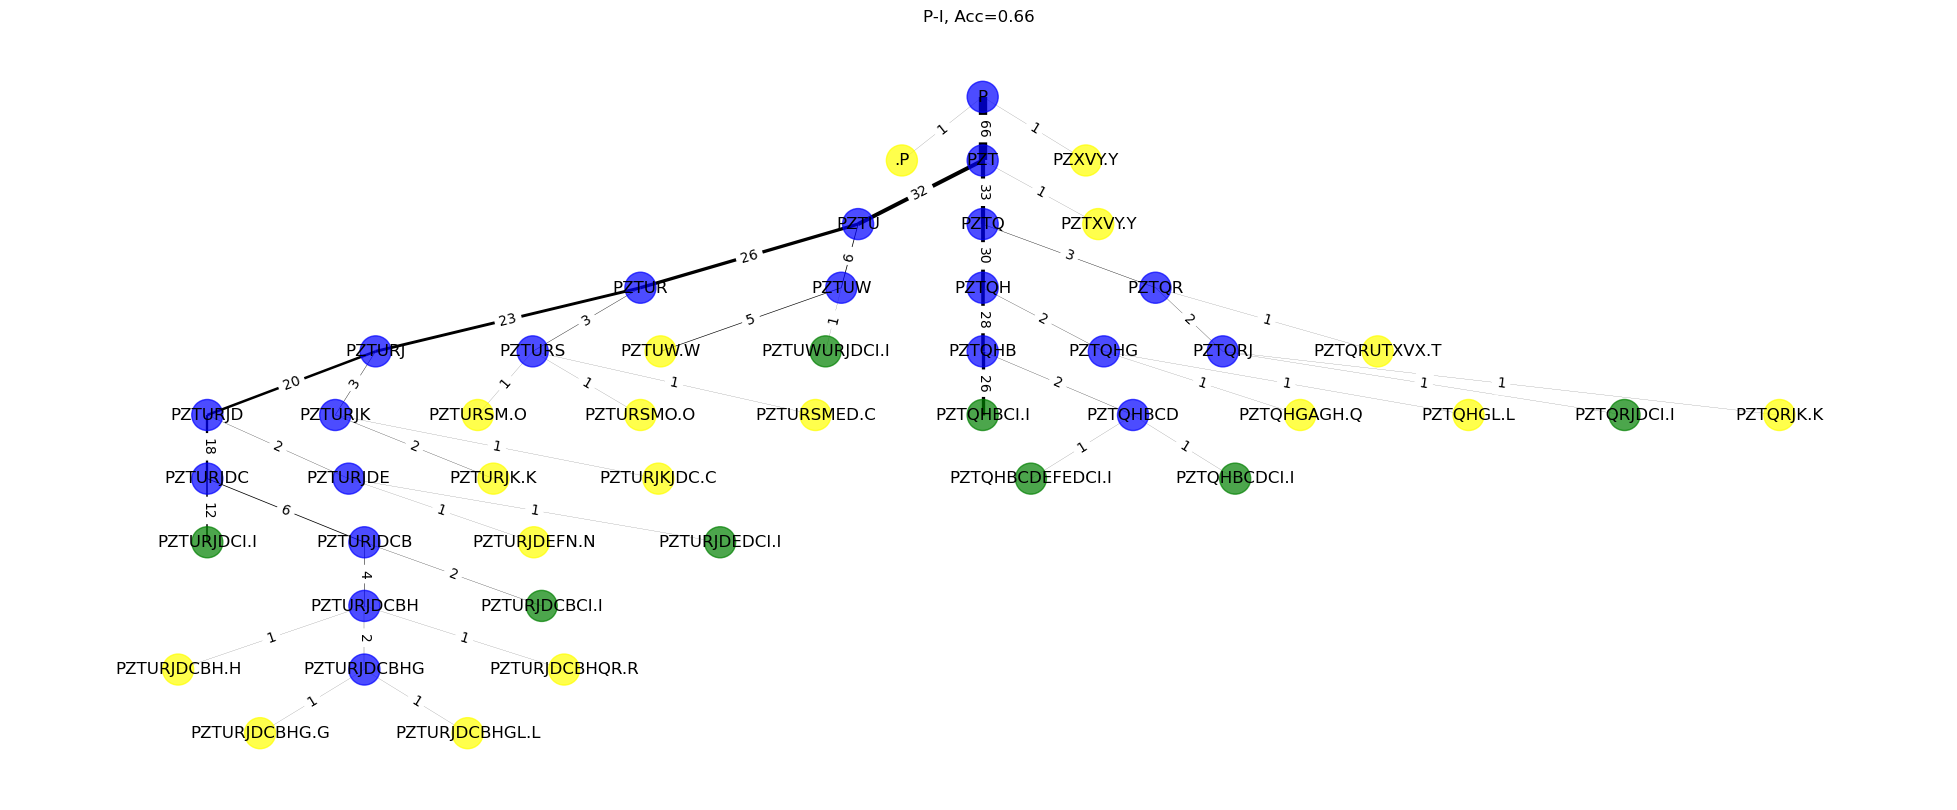

In [48]:
########################################
## One Example (ugly but informative) ##
########################################
# start_node, end_node = ("N", "Y")
start_node, end_node = ("P", "I")

fig, axes = plt.subplots(1, 1, figsize=(25,10))
this_df = test_df[(test_df["StartAt"] == start_node) & (test_df["EndAt"] == end_node)]

trajs = generate_trajs_from_df(this_df)
print(f"Num trajectories: {len(trajs)}")
G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

ax = axes

plot_flow_tree(G, f"{start_node}-{end_node}, Acc={this_df['path_mean_acc'].iloc[0]:.2f}", ax, just_edges=False, edge_boldness=1)
plt.show()

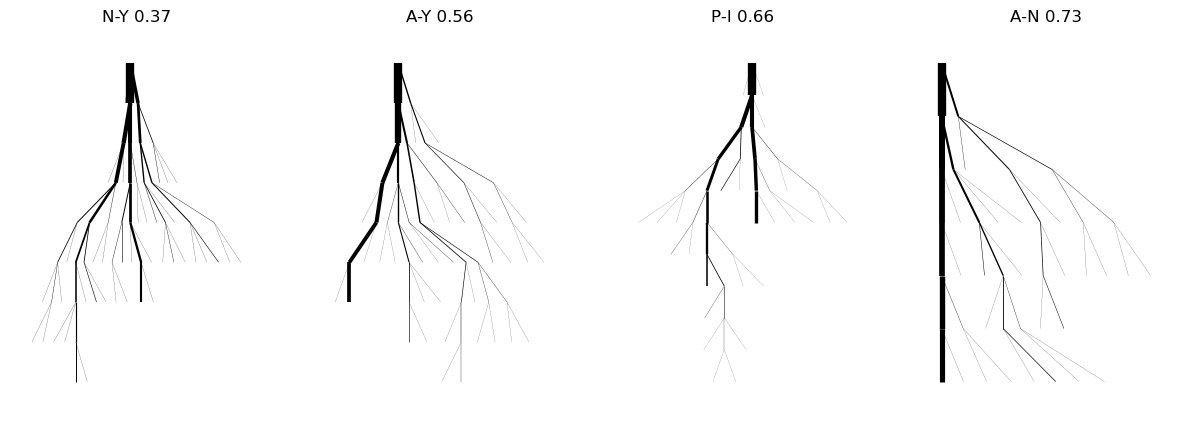

N-Y 0.37


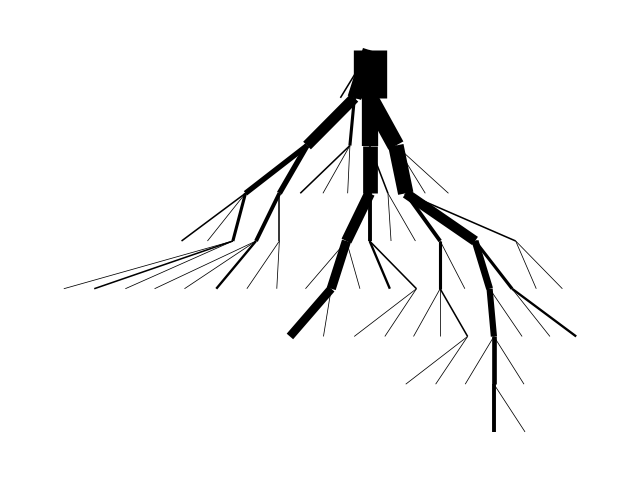

A-Y 0.56


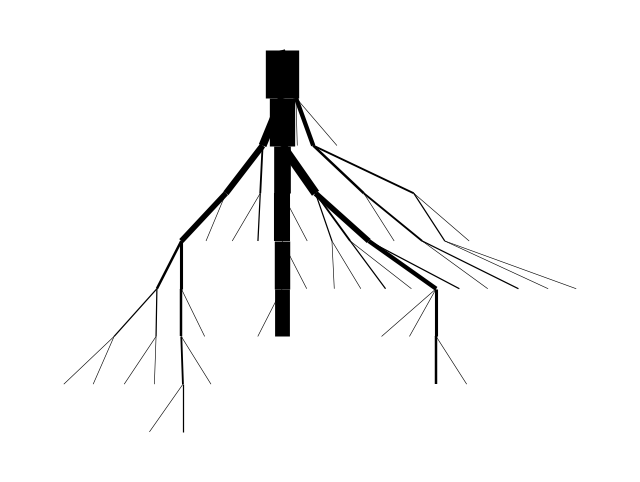

P-I 0.66


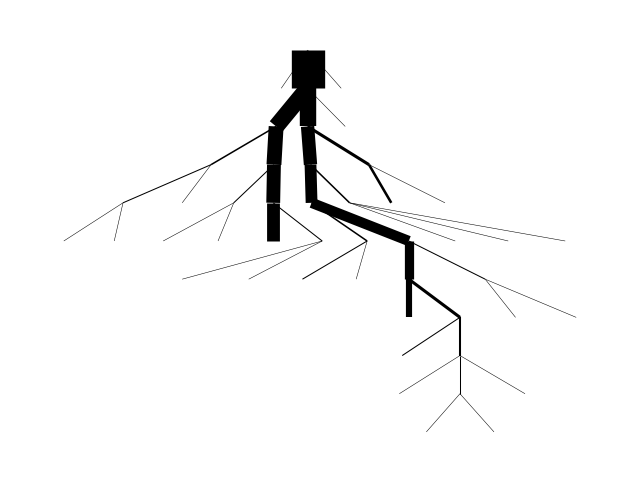

A-N 0.73


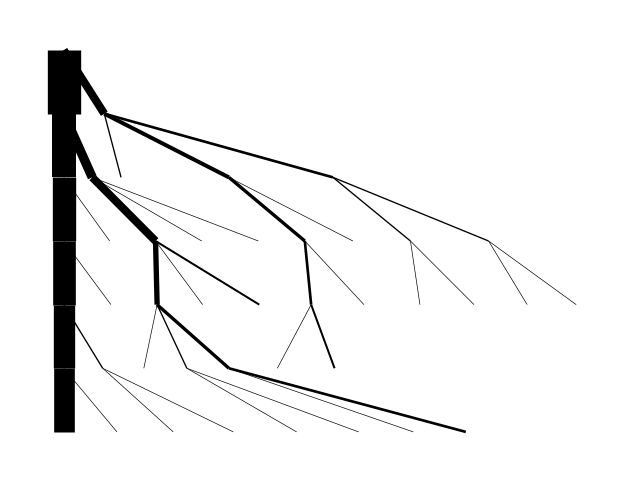

In [88]:
##############################
## Four Examples (prettier) ##
##############################
paths_to_plot = [("N", "Y"), ("A", "Y"), ("P", "I"), ("A", "N")]

fig, axes = plt.subplots(1, len(paths_to_plot), figsize=(15,5))
for i, (start_node, end_node) in enumerate(paths_to_plot):
    this_df = test_df[(test_df["StartAt"] == start_node) & (test_df["EndAt"] == end_node)]# & test_df["accuracy"]]

    acc = this_df["path_mean_acc"].iloc[0]
    trajs = random.sample(generate_trajs_from_df(this_df), min(67, len(generate_trajs_from_df(this_df))))
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    
    plot_flow_tree(G, f"{start_node}-{end_node} {acc:.2f}", axes[i], just_edges=True)

plt.show()

for i, (start_node, end_node) in enumerate(paths_to_plot):
    this_df = test_df[(test_df["StartAt"] == start_node) & (test_df["EndAt"] == end_node)]# & test_df["accuracy"]]

    acc = this_df["path_mean_acc"].iloc[0]
    trajs = random.sample(generate_trajs_from_df(this_df), min(67, len(generate_trajs_from_df(this_df))))
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    
    print(f"{start_node}-{end_node} {acc:.2f}")
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_flow_tree(G, "", ax, just_edges=True, edge_boldness=4)
    plt.show()

## 4. Plot all path Flow Trees

In [253]:
## Generate all by path
flow_trees = []
paths = []
accs = []
tree_dict = {}
winner_tree_dict = {}
loser_tree_dict = {}
sample_size_all = test_df.groupby(["StartAt", "EndAt"]).count().min()[0]
sample_size_succ = test_df[test_df["accuracy"]].groupby(["StartAt", "EndAt"]).count().min()[0]
sample_size_unsucc = test_df[~test_df["accuracy"]].groupby(["StartAt", "EndAt"]).count().min()[0]

print(sample_size_all, sample_size_succ, sample_size_unsucc)

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trjs = generate_trajs_from_df(group)
    trajs = random.sample(trjs, sample_size_all)

    # trajs = generate_trajs_from_df(group)
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    flow_trees.append(new_G)
    accs.append(group["path_mean_acc"].iloc[0])
    paths.append((start_node, end_node))
    tree_dict[(start_node, end_node)] = [new_G, group["path_mean_acc"].iloc[0]]

    group["accuracy"] = group["accuracy"].astype(bool)

    # WINNERS ONLY
    trjs = generate_trajs_from_df(group[group["accuracy"]])
    trajs = random.sample(trjs, sample_size_succ)
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    winner_tree_dict[(start_node, end_node)] = G

    # LOSERS ONLY
    trjs = generate_trajs_from_df(group[~group["accuracy"]])
    trajs = random.sample(trjs, sample_size_unsucc)    
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    loser_tree_dict[(start_node, end_node)] = G

accs = np.array(accs)

34 18 14


#### only plot 6

In [225]:
len(flow_trees)

310

0.4375
0.5294117647058824
0.5555555555555556
0.5882352941176471
0.6507936507936508
0.7258064516129032


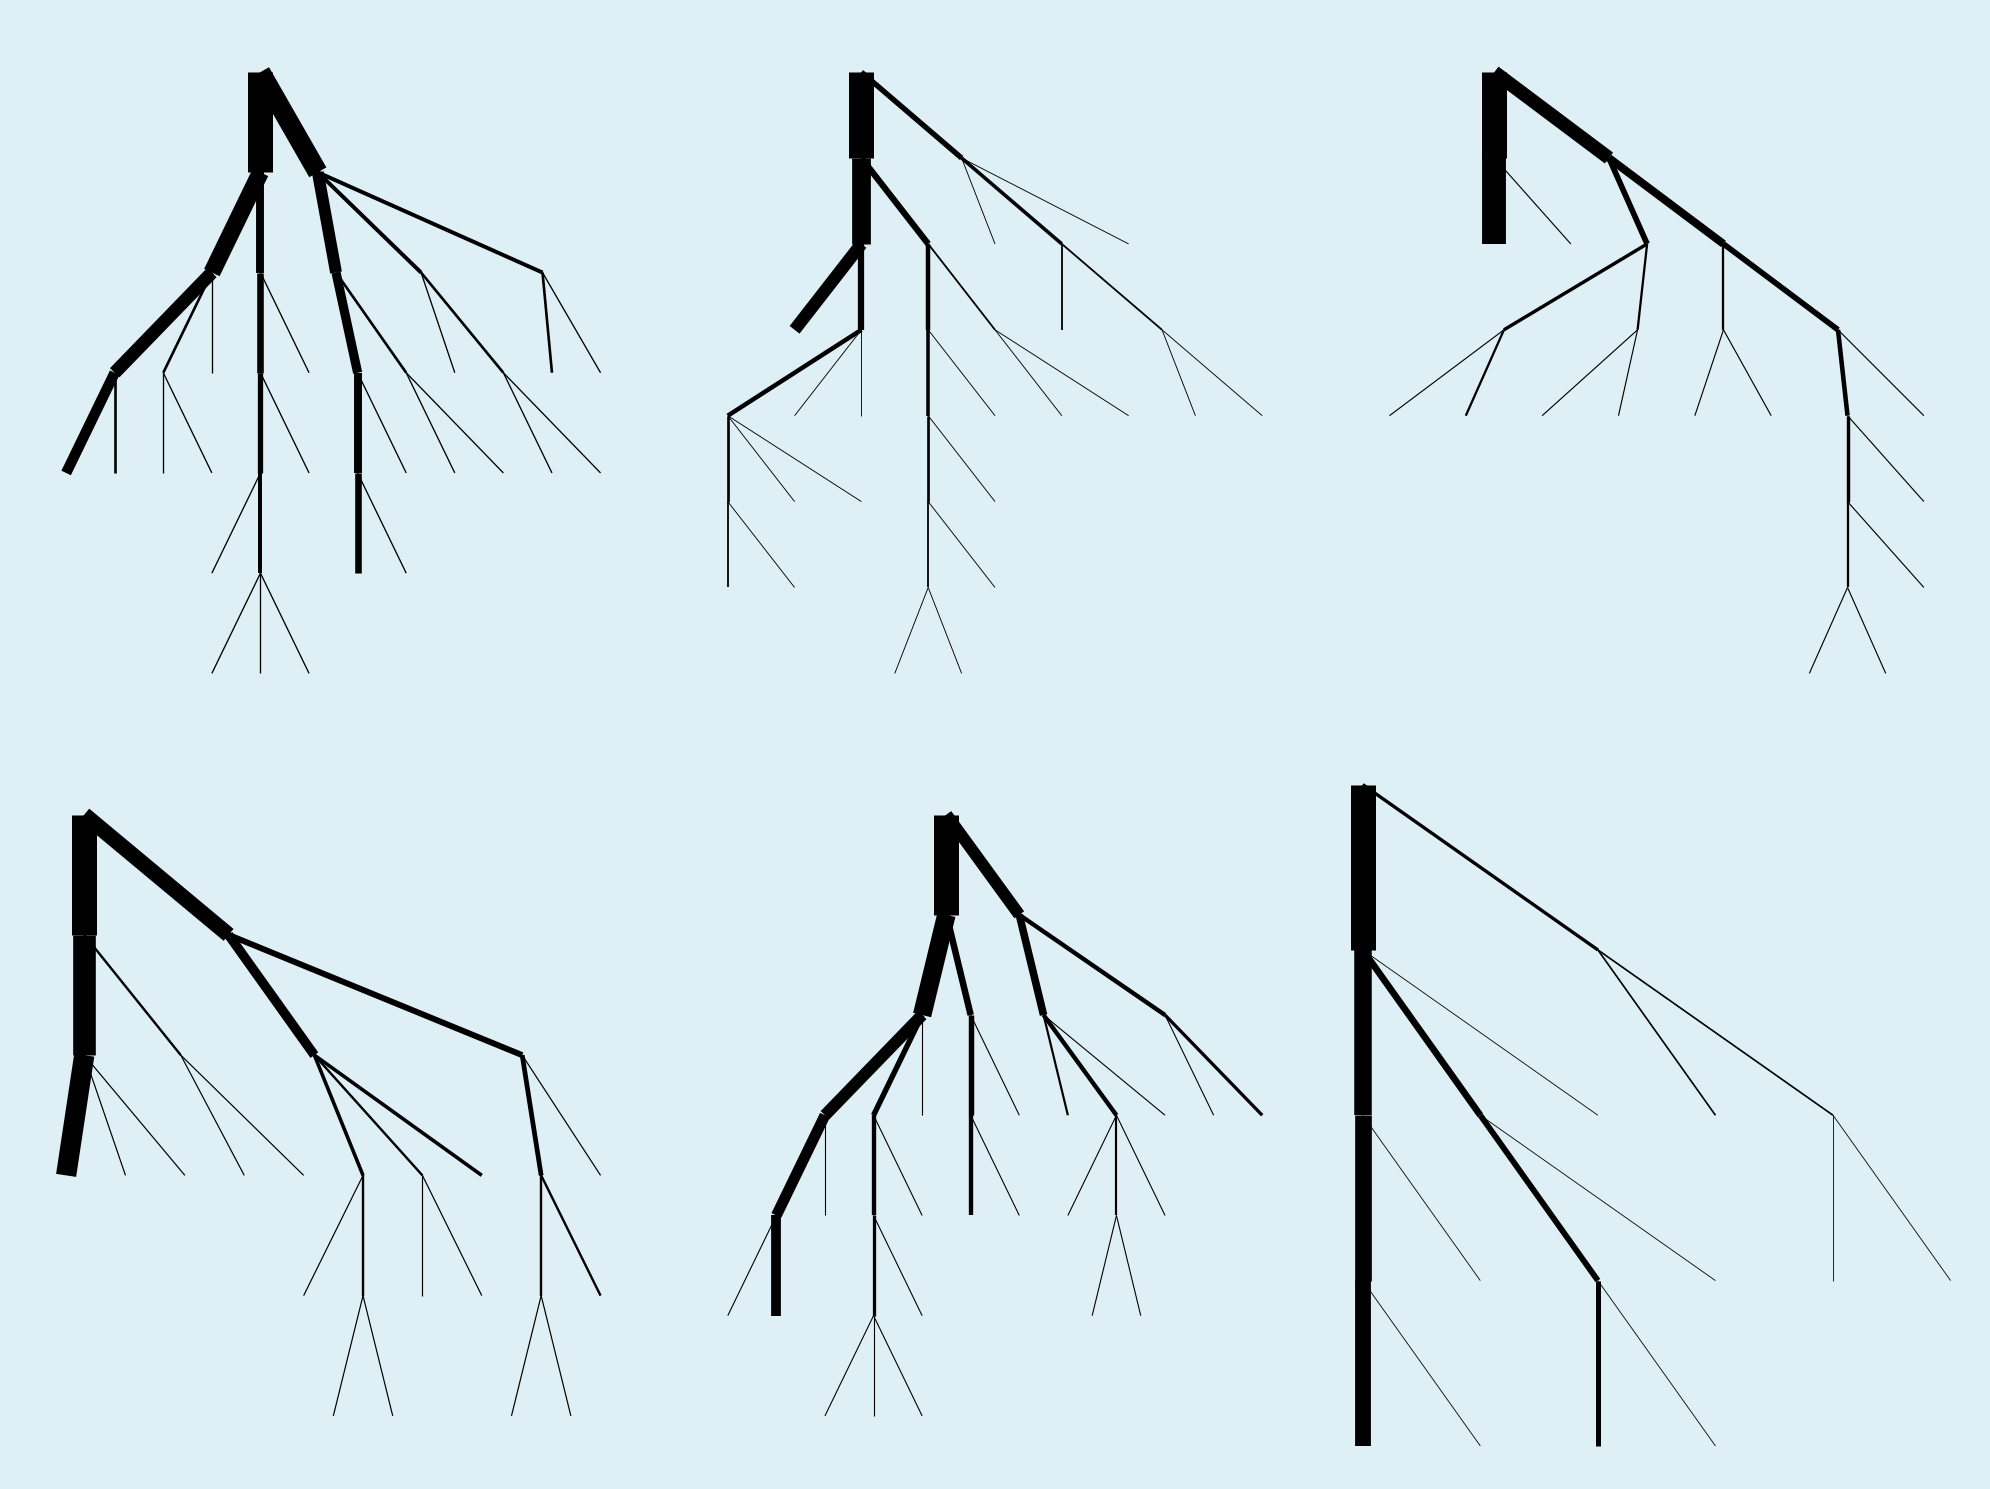

0.4375
0.5294117647058824
0.5555555555555556
0.5882352941176471
0.6507936507936508
0.7258064516129032


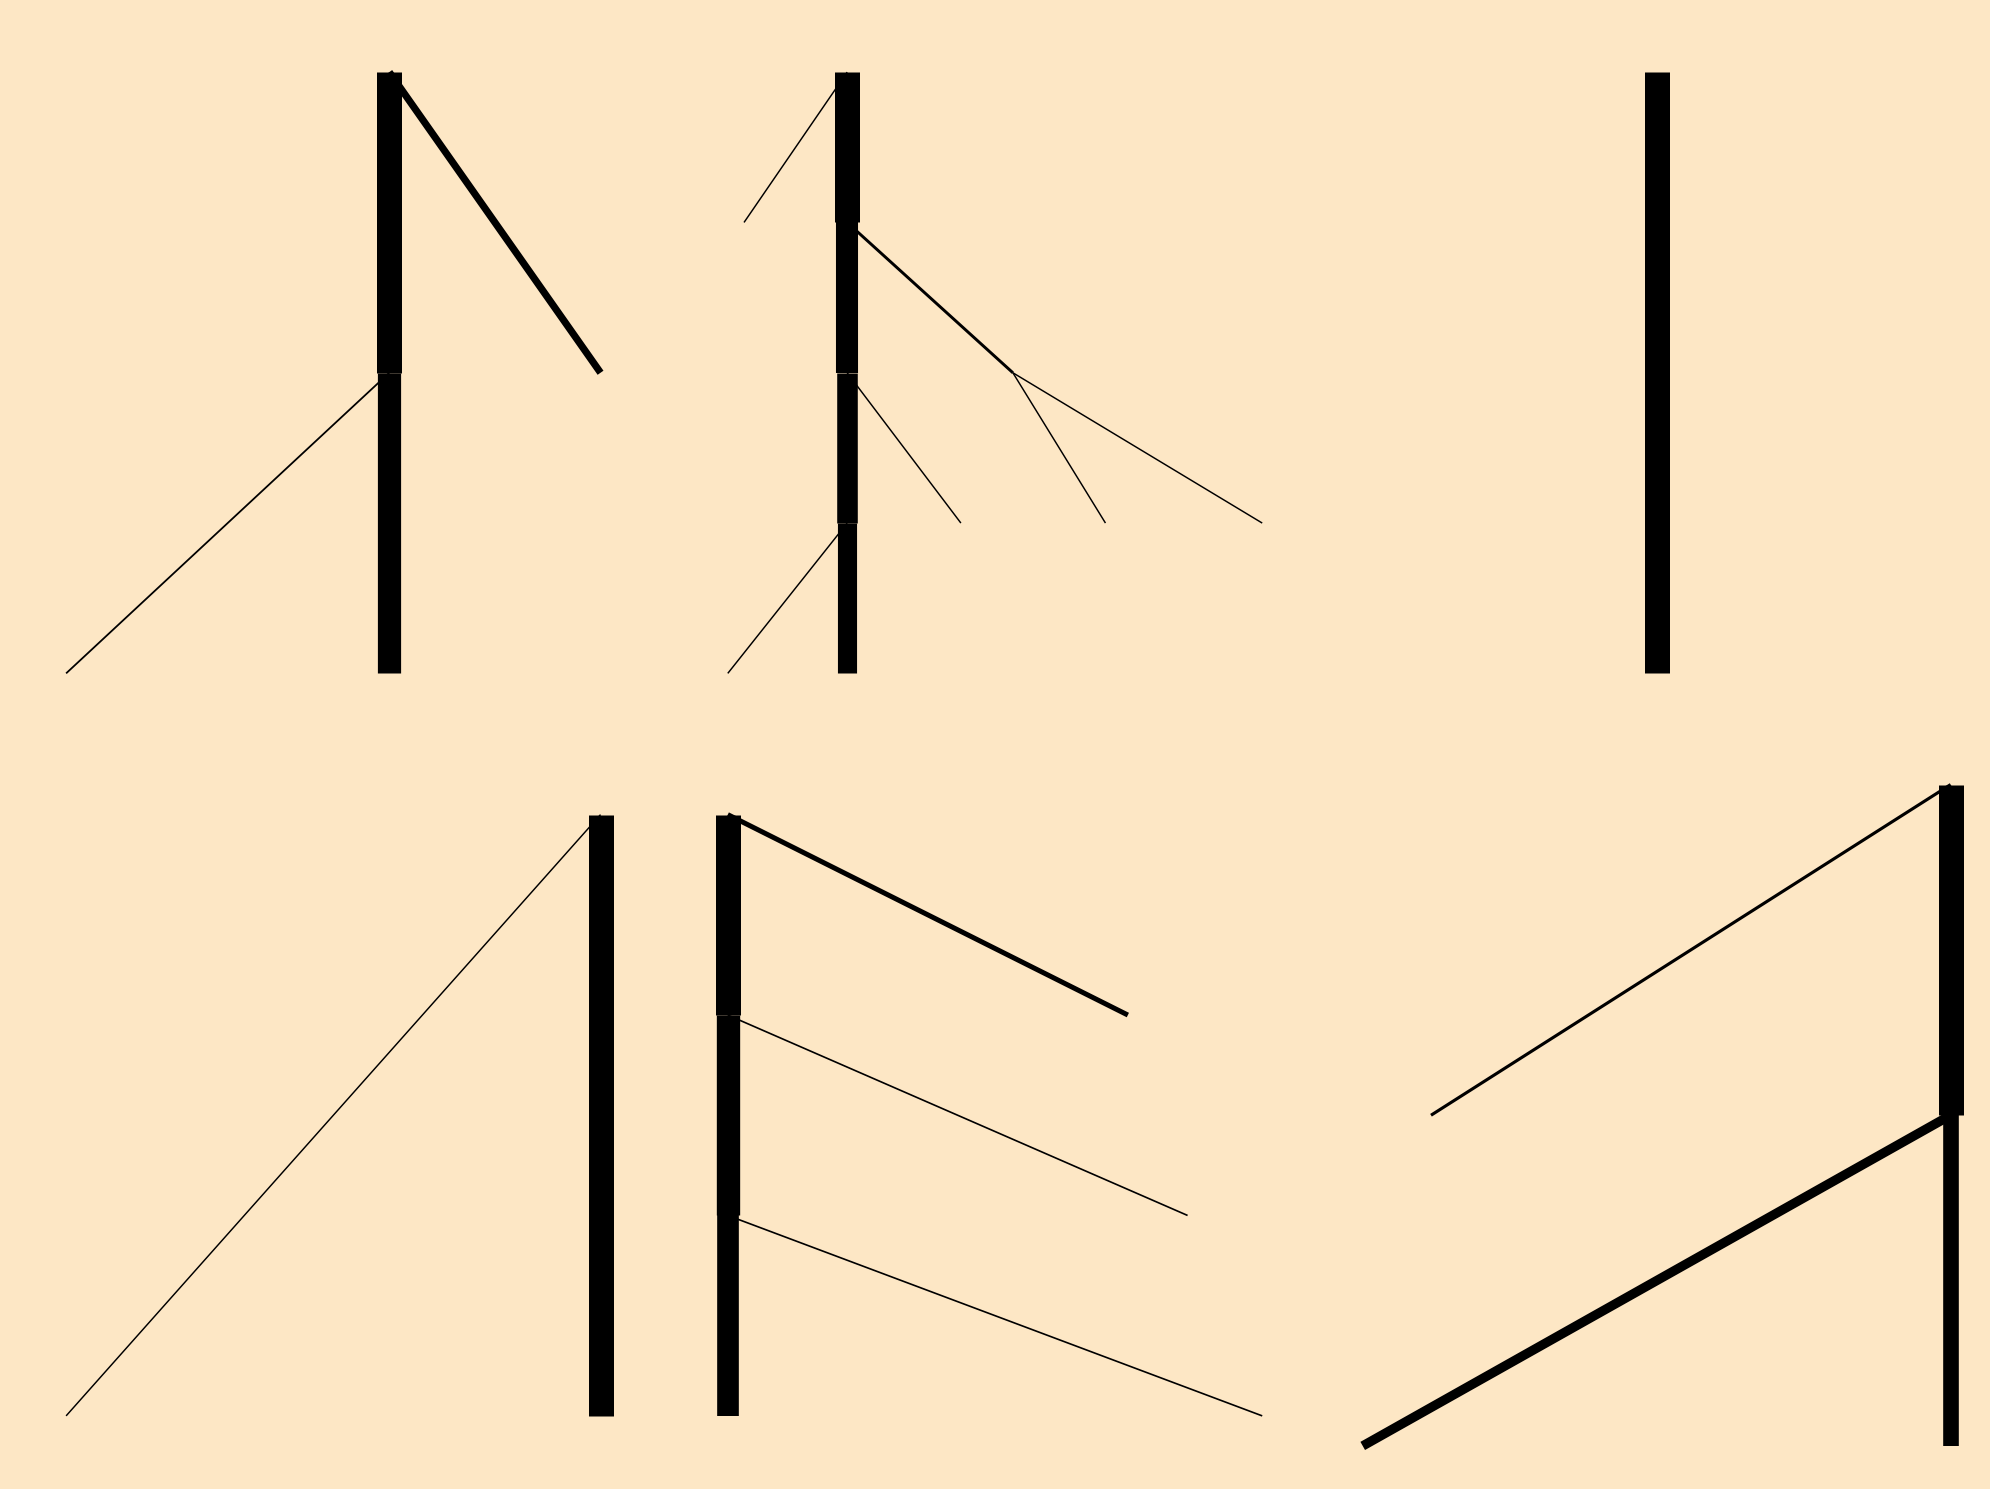

0.4375
0.5294117647058824
0.5555555555555556
0.5882352941176471
0.6507936507936508
0.7258064516129032


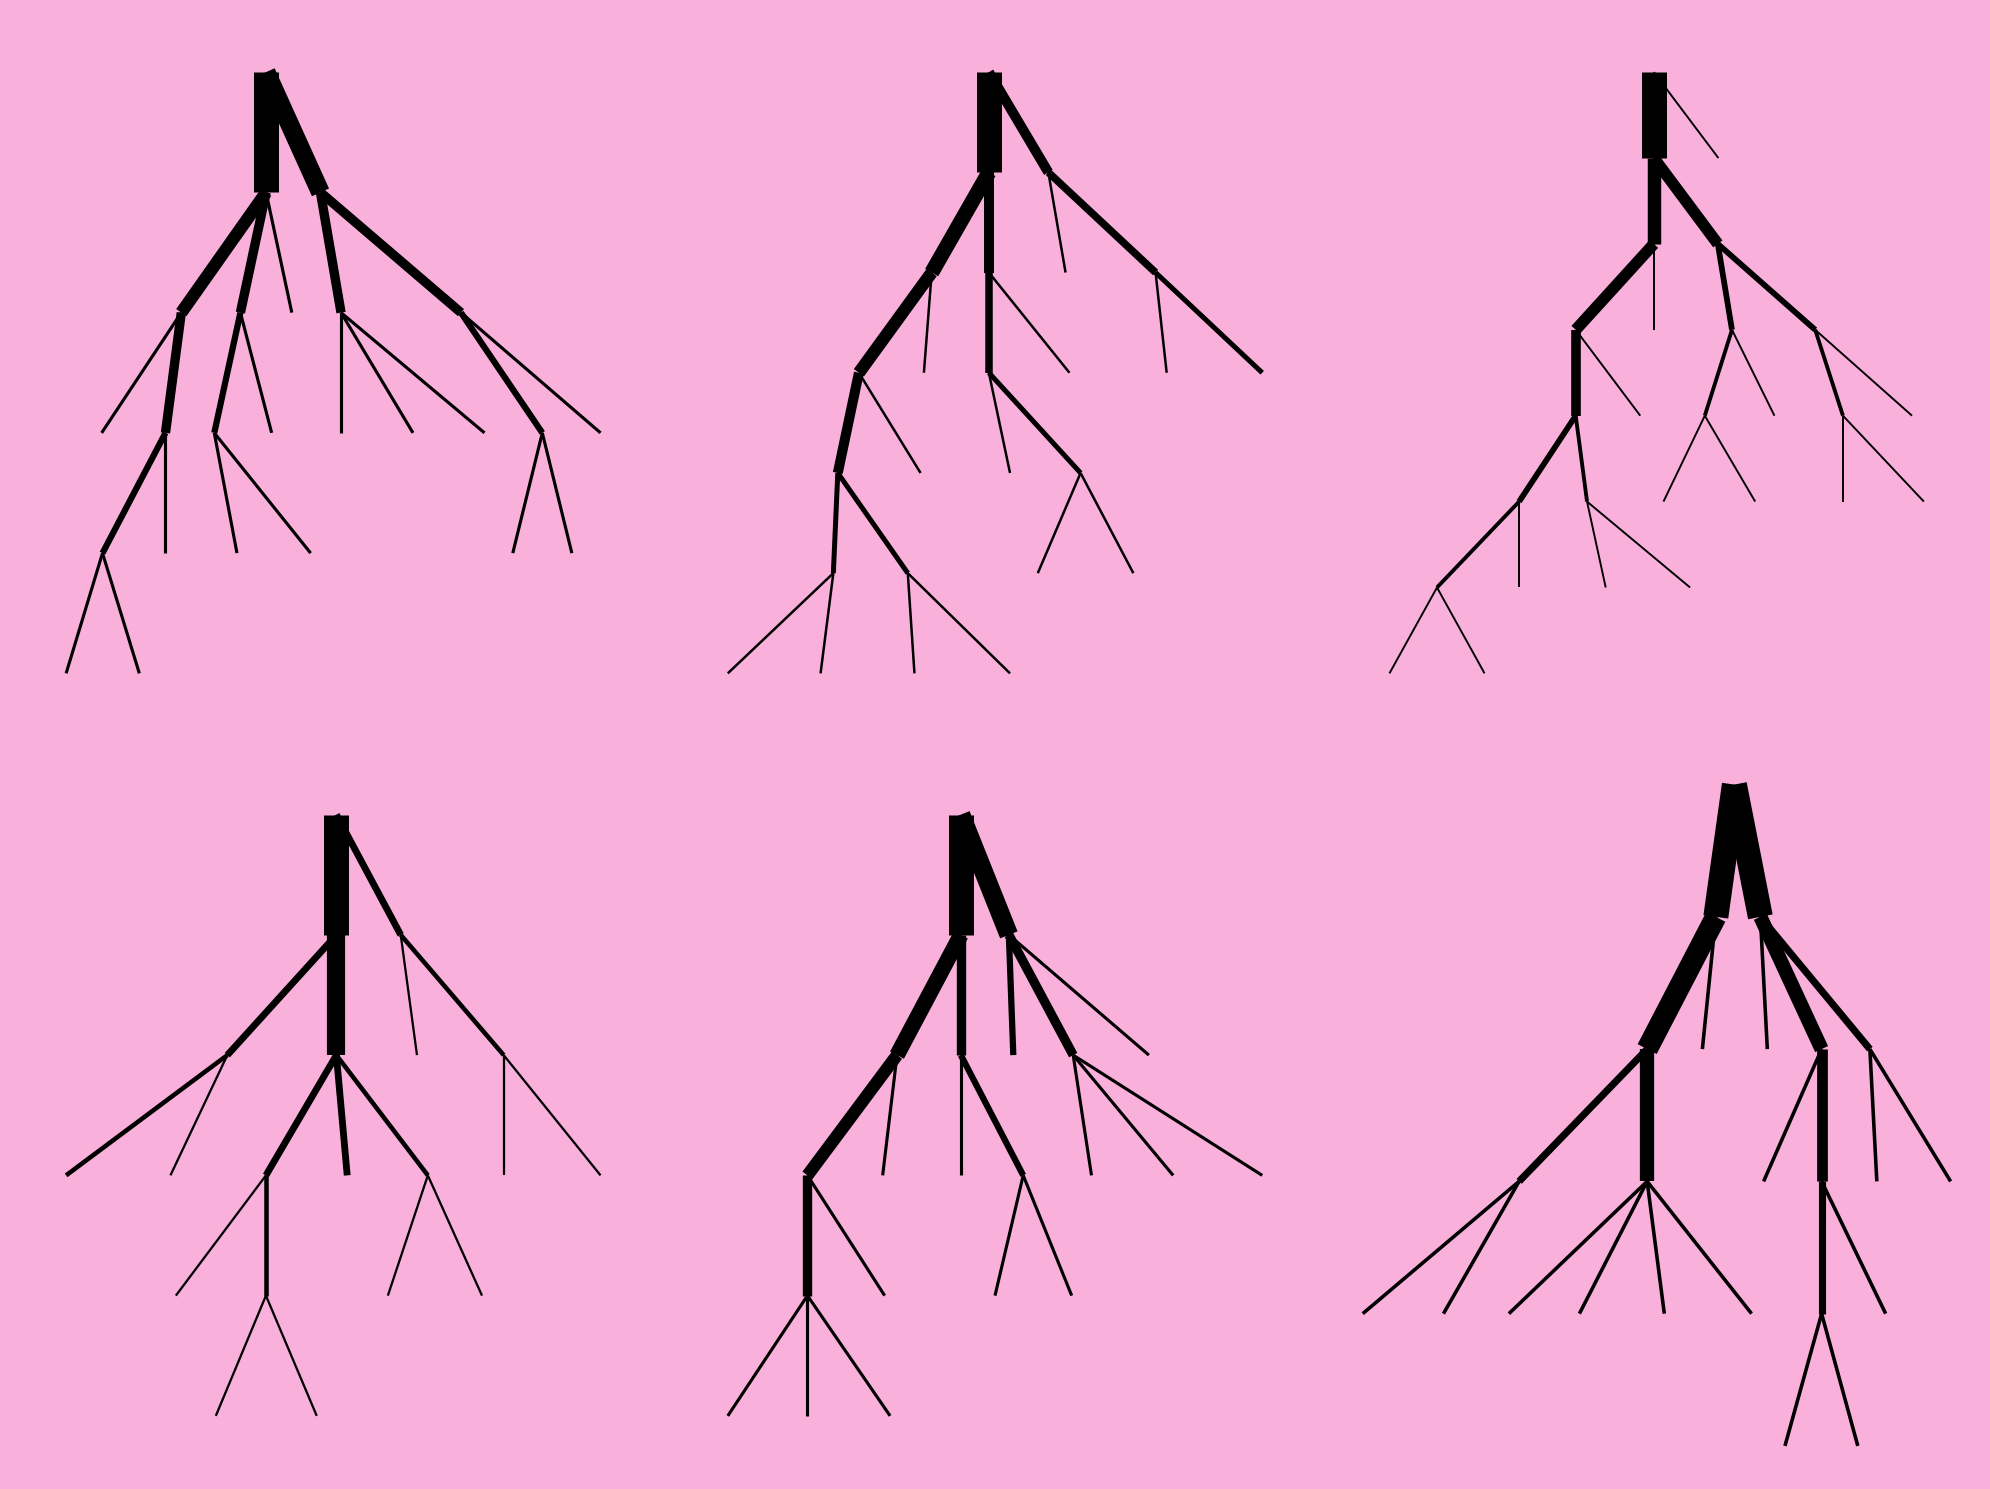

In [264]:
# need to convert to rgba to have semi-transparent background to match figure colour
# silly
def hex_to_rgb_add_alpha(h, a):
    rgb = [int(h[i:i+2], 16)/255. for i in (0, 2, 4)]
    return (rgb[0], rgb[1], rgb[2], a)

num_rows = 2
num_cols = 3
step = 72 // (num_rows*num_cols)
offset = 3

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20,15), layout="tight", facecolor=hex_to_rgb_add_alpha("d0e9f1", 0.7))

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
for i in range(0, len(sorted_order), step):
    tree_index = sorted_order[i+offset]

    G = flow_trees[tree_index]
    
    # Convert from i to column-major indices
    col = (i//step) // num_rows
    row = (i//step) % num_rows
    ax = axes[row][col]
    print(accs[tree_index])
    plot_flow_tree(G, f"{'-'.join(paths[tree_index])} {accs[tree_index]:.2f}", ax, edge_boldness=3.0, no_title=True, just_edges=True)
fig.subplots_adjust(hspace=0.1, wspace=0.1)
plt.margins(x=-.0, y=0)
plt.show()


fig, axes = plt.subplots(num_rows, num_cols, figsize=(20,15), layout="tight", facecolor=hex_to_rgb_add_alpha("fbb042", 0.3))

for i in range(0, len(sorted_order), step):
    tree_index = sorted_order[i+offset]
    G = winner_tree_dict[paths[tree_index]]
    
    # Convert from i to column-major indices
    col = (i//step) // num_rows
    row = (i//step) % num_rows
    
    ax = axes[row][col]

    print(accs[tree_index])
    plot_flow_tree(G, f"{'-'.join(paths[tree_index])} {accs[tree_index]:.2f}", ax, edge_boldness=3.0, no_title=True, just_edges=True)
fig.subplots_adjust(hspace=0.1, wspace=0.1)
plt.margins(x=-.0, y=0)
plt.show()

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20,15), layout="tight", facecolor=hex_to_rgb_add_alpha("ec008c", 0.3))

for i in range(0, len(sorted_order), step):
    tree_index = sorted_order[i+offset]
    G = loser_tree_dict[paths[tree_index]]
    
    # Convert from i to column-major indices
    col = (i//step) // num_rows
    row = (i//step) % num_rows
    
    ax = axes[row][col]

    print(accs[tree_index])
    plot_flow_tree(G, f"{'-'.join(paths[tree_index])} {accs[tree_index]:.2f}", ax, edge_boldness=3.0, no_title=True, just_edges=True)
plt.subplots_adjust(hspace=0.1, wspace=0.1)
plt.margins(x=-.0, y=-.0)
plt.show()


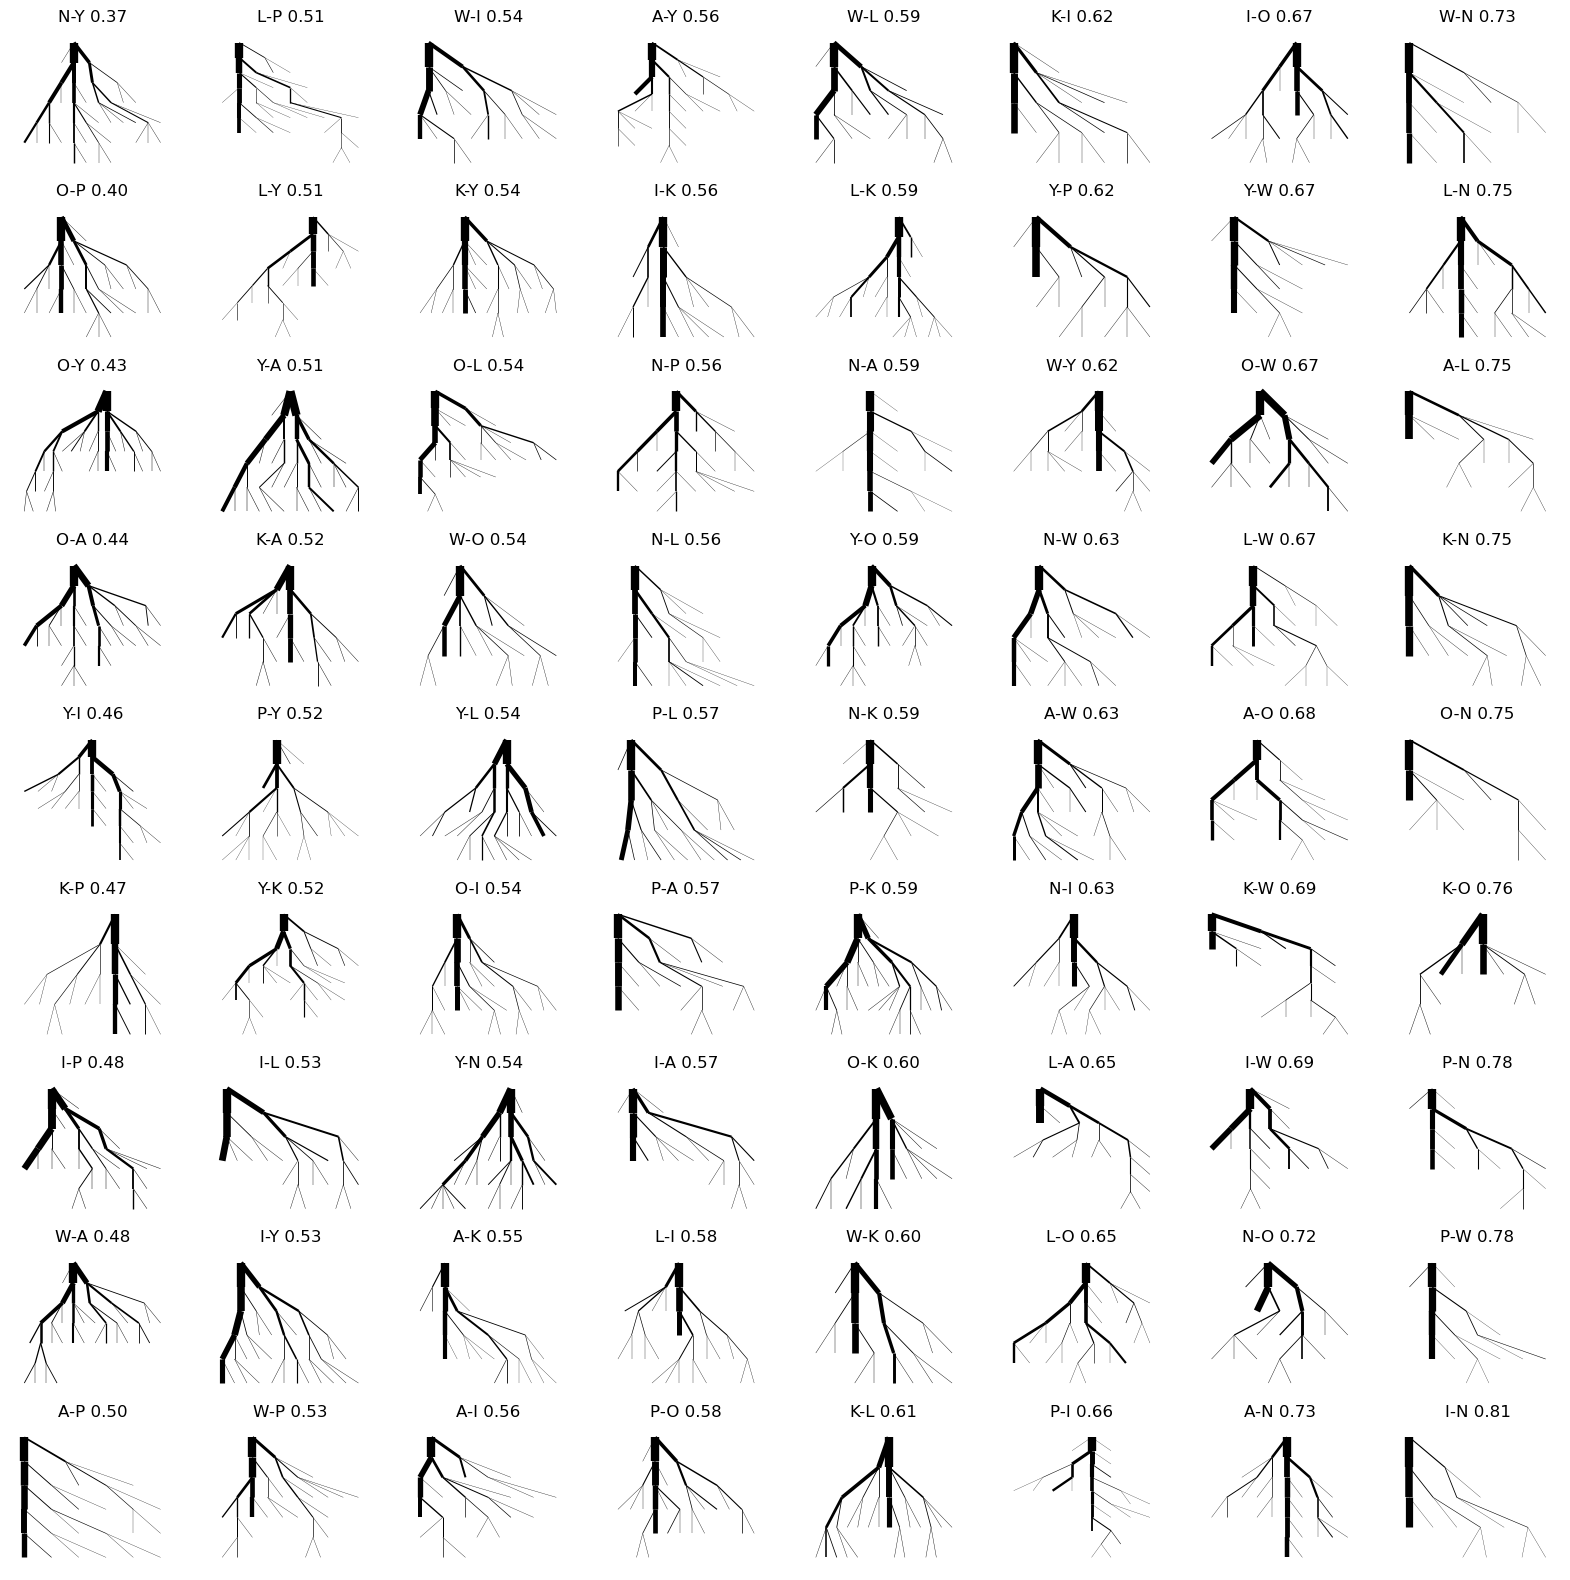

In [263]:

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]

fig, axes = plt.subplots(9, 8, figsize=(20,20))
for i, tree_index in enumerate(sorted_order):
    G = flow_trees[tree_index]
    
    # Convert from i to column-major indices
    col = i // 9
    row = i % 9
    ax = axes[row][col]
    plot_flow_tree(G, f"{'-'.join(paths[tree_index])} {accs[tree_index]:.2f}", ax, no_title=False, just_edges=True)
fig.savefig("figures/test_flow_trees_by_acc-all.png")
plt.show()


# fig, axes = plt.subplots(9, 8, figsize=(20,20))
# for i, tree_index in enumerate(sorted_order):
#     G = winner_tree_dict[paths[tree_index]]
    
#     # Convert from i to column-major indices
#     col = i // 9 
#     row = i % 9
#     ax = axes[row][col]
#     plot_flow_tree(G, f"{'-'.join(paths[tree_index])} {accs[tree_index]:.2f}", ax, no_title=False, just_edges=True)
# fig.savefig("figures/test_flow_trees_by_acc-only_winners.png")
# plt.show()


# fig, axes = plt.subplots(9, 8, figsize=(20,20))
# for i, tree_index in enumerate(sorted_order):
#     G = loser_tree_dict[paths[tree_index]]
    
#     # Convert from i to row-major indices
#     col = i % 8
#     row = i // 8

#     ax = axes[row][col]
#     plot_flow_tree(G, f"{'-'.join(paths[tree_index])} {accs[tree_index]:.2f}", ax, no_title=False, just_edges=True)

# # fig.suptitle("ONLY LOSERS Test-path trees sorted by subject-mean path accuracy")
# fig.savefig("figures/test_flow_trees_by_acc-only_losers.png")

# plt.show()

## 5. Regression

### Helper fns

In [271]:
def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    # leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]

    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Diameter
    diameter = nx.diameter(graph)

    backbone_path, max_weight, weights = get_heaviest_path(graph, root)
    print(max_weight)
    backbone_thickness = np.mean(weights) / max_weight
    print(backbone_thickness)
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Put all features in a list
    features = [
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ]
    
    return features

def extract_static_features(df):
    euclid_distance = df["Euc.Distance"].mode().iloc[0]
    path_distance = df["Path.Distance"].mode().iloc[0]
    num_nodes = df["Num.Nodes"].mode().iloc[0]
    
    avg_path_dist_traveled = df["path_dist_trav"].mean()
    avg_nodes_count = df["nodes_count"].mean()
    avg_turns_count = df["turns_count"].mean()

    return [euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count]


def extract_static_features(df):
    euclid_distance = df["Euc.Distance"].mode().iloc[0]
    path_distance = df["Path.Distance"].mode().iloc[0]
    num_nodes = df["Num.Nodes"].mode().iloc[0]
    
    avg_path_dist_traveled = df["path_dist_trav"].mean()
    avg_nodes_count = df["nodes_count"].mean()
    avg_turns_count = df["turns_count"].mean()

    return [euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count]




### Compute features

In [55]:
# flow_tree_features = np.array([extract_tree_features(flow_tree, 0) for flow_tree in flow_trees])
# flow_tree_diameters = np.array([[nx.diameter(G)] for G in flow_trees])

In [292]:
only_winners = False
only_losers = False

static_features = []
flow_tree_features = []
flow_trees = []
accuracies = []

if only_losers:
    min_sample_size = test_df[~test_df["accuracy"]].groupby(["StartAt", "EndAt"]).count().min()[0]
elif only_winners:
    min_sample_size = test_df[test_df["accuracy"]].groupby(["StartAt", "EndAt"]).count().min()[0]
else:
    min_sample_size = test_df.groupby(["StartAt", "EndAt"]).count().min()[0]
# min_sample_size = 20
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    if only_losers: group = group[~group["accuracy"]]
    elif only_winners: group = group[group["accuracy"]]
    
    acc = group["path_mean_acc"].iloc[0]

    if len(group) < min_sample_size: 
        print("AJ")
        continue

    # sample 5 times for each flow tree
    for i in range(5):
        
        sample_df1 = group.sample(n=min_sample_size, random_state=i, replace=False) 

        trajs1 = np.array(sample_df1["trajs"])
        G1 = generate_flow_tree_from_trajs(trajs1, END_NODE=end_node)
        new_G1 = nx.relabel.convert_node_labels_to_integers(G1, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero

        flow_trees.append(new_G1)
        accuracies.append(acc)
        
        static_features.append(extract_static_features(sample_df1))
        flow_tree_features.append(extract_tree_features(new_G1, 0))

static_features = np.array(static_features)
flow_tree_features = np.array(flow_tree_features)
accuracies = np.array(accuracies)

82
0.25
63
0.25
57
0.3333333333333333
47
0.2
79
0.25
61
0.3333333333333333
80
0.2
91
0.19999999999999998
73
0.25
62
0.25
51
0.5
25
0.16666666666666669
49
0.5
45
0.5
46
0.5
98
0.2
94
0.2
101
0.19999999999999998
62
0.33333333333333337
85
0.2
91
0.19999999999999998
79
0.25
72
0.25
89
0.2
74
0.25
110
0.2
106
0.19999999999999998
119
0.16666666666666666
111
0.16666666666666666
96
0.19999999999999998
68
0.25
98
0.2
76
0.25
66
0.25
79
0.2
84
0.2
83
0.2
88
0.2
94
0.2
69
0.25
63
0.3333333333333333
64
0.3333333333333333
57
0.3333333333333333
68
0.33333333333333337
63
0.3333333333333333
61
0.3333333333333333
86
0.25
78
0.25
77
0.25
58
0.3333333333333333
57
0.3333333333333333
57
0.3333333333333333
57
0.3333333333333333
57
0.3333333333333333
57
0.3333333333333333
76
0.3333333333333333
104
0.25
103
0.25
111
0.25
111
0.25
47
0.25
50
0.33333333333333337
58
0.19999999999999998
52
0.3333333333333333
65
0.2
74
0.2
93
0.2
69
0.25
54
0.25
52
0.2
50
0.33333333333333337
60
0.3333333333333333
48
0.333333333333

In [162]:
def plot_four_tree_metric(to_plot, flip_colors=False):
    line_color, dot_color = ("#FF5A5F", "#2A2D7C") if not flip_colors else ("#2A2D7C", "#FF5A5F")

    fig = plt.figure(figsize=(6, 6))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, .1], hspace=0.05)

    ax = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])

    ax.plot([1,2,3,4], to_plot, c=line_color, linewidth=4)
    for ii in range(1,5):
        ax.scatter(ii, to_plot[ii-1], marker="$" + str(ii) + "$", c=dot_color, s=1500, zorder=3)

    fudge = (np.max(to_plot) - np.min(to_plot)) * .1
    ylim = [np.min(to_plot) - fudge, np.max(to_plot) + fudge]
    ax.set_ylim(*ylim)  # most of data
    ax2.set_ylim(0, .1)  # emptiness

    d = .3  # proportion of vertical to horizontal extent of the slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=30,
                linestyle="none", color='k', mec='k', mew=2, clip_on=False)
    ax.plot([0], [0], transform=ax.transAxes, **kwargs)
    ax2.plot([0], [1], transform=ax2.transAxes, **kwargs)

    plt.yticks([0])

    for axx in [ax, ax2]:
        axx.spines["top"].set_visible(False)
        axx.spines["right"].set_visible(False)        
        axx.spines["bottom"].set_visible(False)
        axx.xaxis.set_visible(False)

        axx.spines["left"].set_linewidth(2.5)
        axx.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)

    plt.margins(x=.1, y=.1)
    plt.show()


NY [12.9059095, 33.75, 10.0, 29.261904761904763, 9.34920634920635, 7.0476190476190474]
126
0.125
AY [14.80920322, 21.25, 7.0, 25.714285714285715, 8.873015873015873, 7.857142857142857]
197
0.16666666666666669
PI [7.079901129, 22.5, 7.0, 24.88235294117647, 8.264705882352942, 5.617647058823529]
198
0.1
AN [15.18222645, 23.0, 8.0, 26.826612903225808, 9.193548387096774, 7.564516129032258]
218
0.16666666666666669


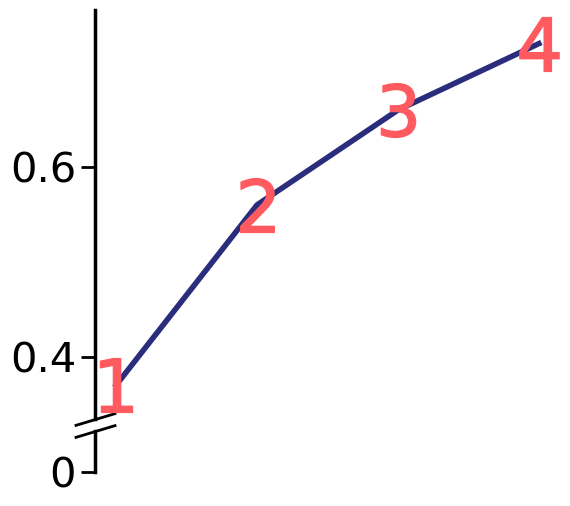

[euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count]


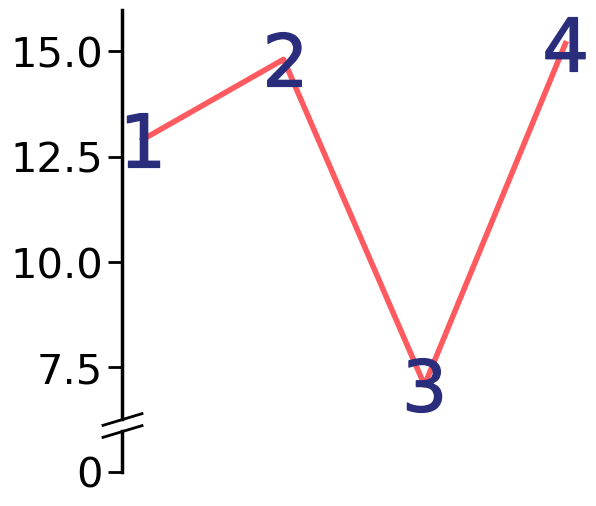

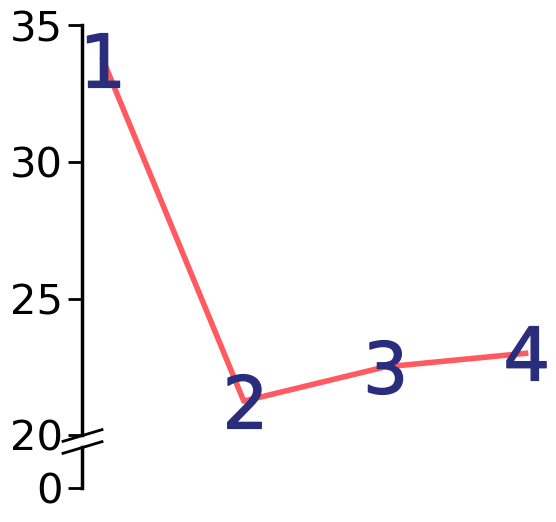

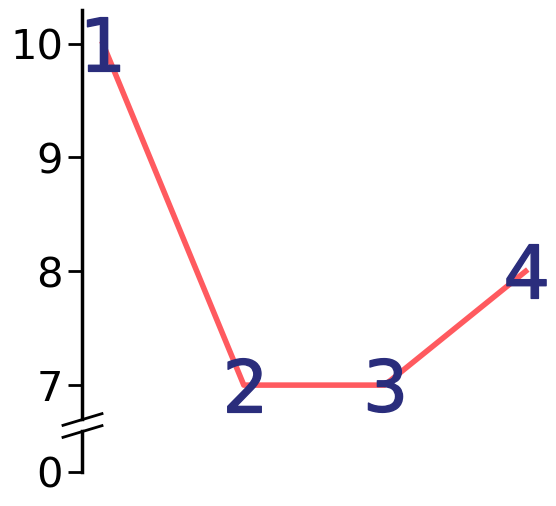

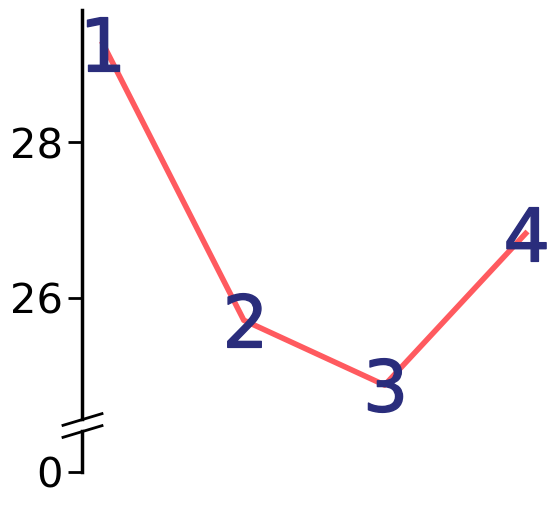

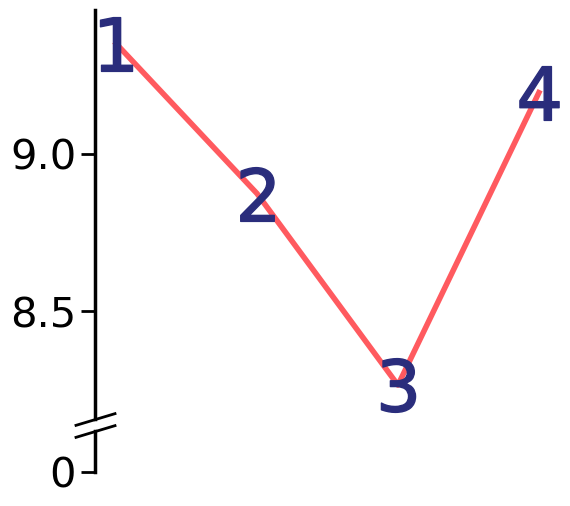

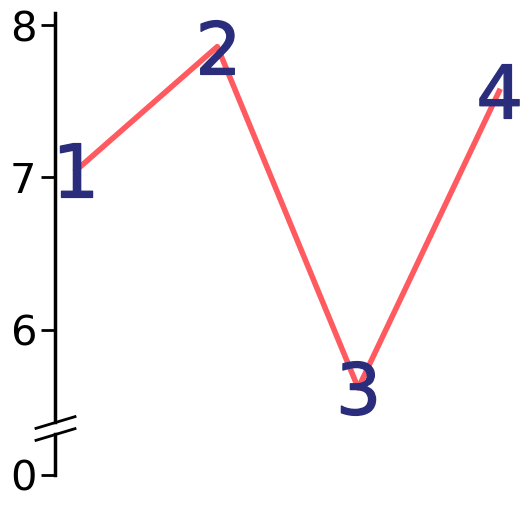

[
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ]


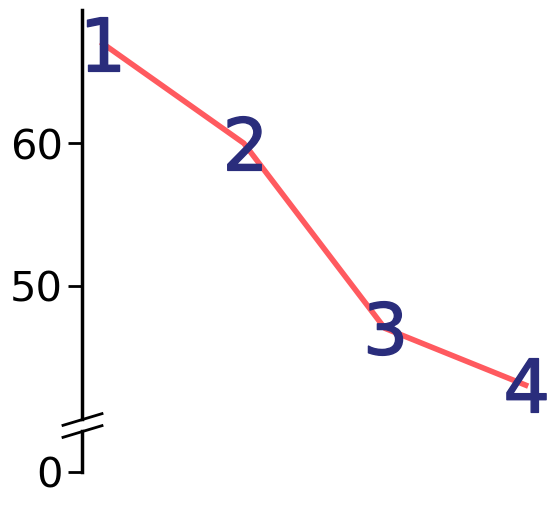

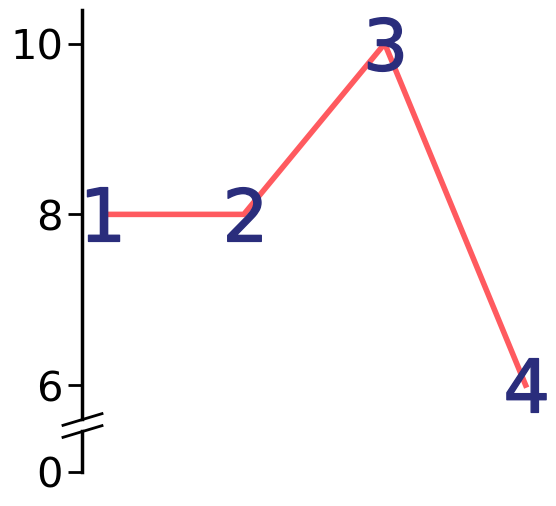

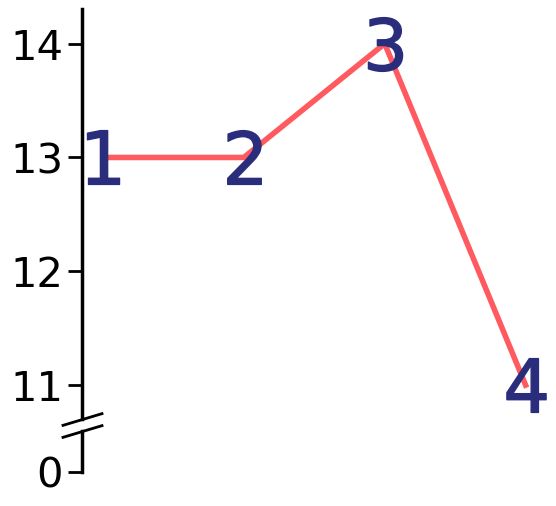

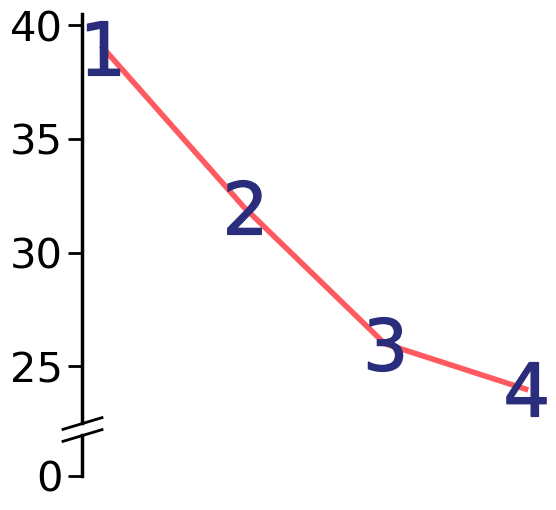

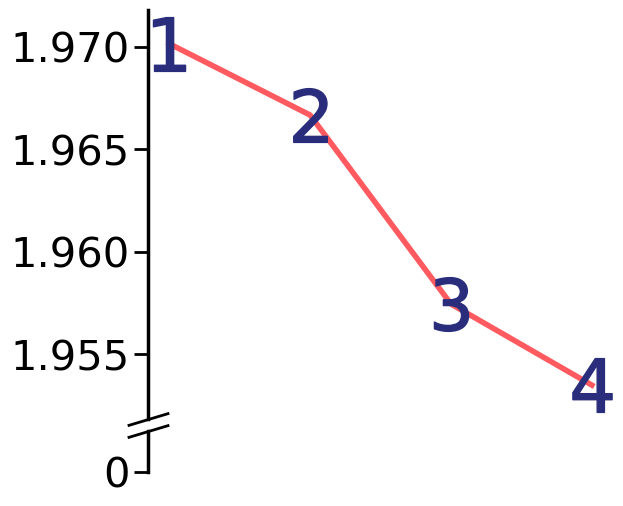

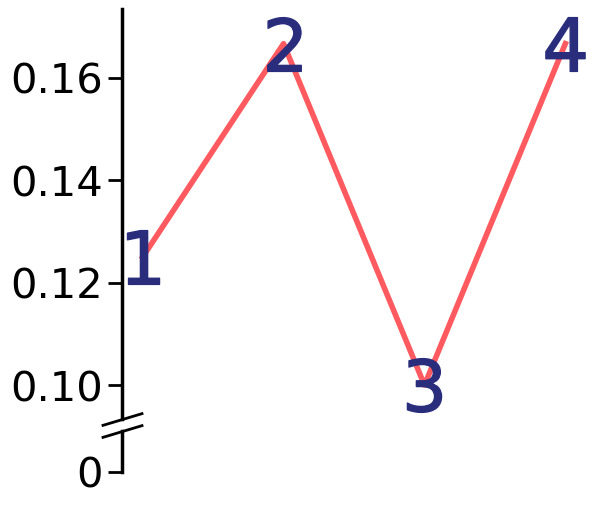

In [218]:
# Silly graphs for just the 4
four_sample_trees = ["NY", "AY", "PI", "AN"]

silly_statics = []
silly_fts = []
for sample_tree in four_sample_trees:
    this_df = test_df[(test_df["StartAt"] == sample_tree[0]) & (test_df["EndAt"] == sample_tree[1])]
    
    print(sample_tree, extract_static_features(this_df))
    silly_statics.append(extract_static_features(this_df))

    trajs1 = np.array(this_df["trajs"])
    G1 = generate_flow_tree_from_trajs(trajs1, END_NODE=end_node)
    new_G1 = nx.relabel.convert_node_labels_to_integers(G1, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero

    silly_fts.append(extract_tree_features(new_G1, 0))


# Plot accuracies
accs = [.37, .56, .66, .73]
plot_four_tree_metric(accs, flip_colors=True)

silly_statics = np.array(silly_statics)
silly_fts = np.array(silly_fts)
print("[euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count]")
for i in range(silly_statics.shape[1]):
    plot_four_tree_metric(silly_statics[:,i])

print("""[
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ]""")
for i in range(silly_fts.shape[1]):
    plot_four_tree_metric(silly_fts[:,i])

In [58]:
# Compute embeddings
flow_tree_embedder = kc.Graph2Vec(dimensions=64)
flow_tree_embedder.fit(flow_trees)

flow_tree_embeddings = flow_tree_embedder.infer(flow_trees)

pca = PCA(n_components=2)
reduced_features = pca.fit_transform(flow_tree_embeddings)

# print(reduced_features)

### Run regression

In [290]:
def run_evaluate_regression(X, y, feature_str="", axes=["", "", ""], y_axis=False):
    # Initialize and fit the linear regression model
    model = LinearRegression()
    
    ## K-fold cross validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Store RMSE for each fold
    rmse_list = []

    slopes = []
    
    # Perform the cross-validation
    for train_index, test_index in kf.split(X):
        # Split data
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Train the model
        model.fit(X_train, y_train)
        
        # Predict on the test set
        y_pred = model.predict(X_test)
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        # Append RMSE to the list
        rmse_list.append(rmse)

        slopes.append(model.coef_)
    
    # Convert RMSE list to a numpy array for statistical calculations
    rmse_array = np.array(rmse_list)
    
    mean_rmse = np.mean(rmse_array)
    std_rmse = np.std(rmse_array)
    
    print(f"Mean RMSE: {mean_rmse:0.4f} $\\pm$ {std_rmse:0.5f}")
    
    # Get the regression coefficient and intercept
    slopes = np.array(slopes)
    slope = np.mean(np.abs(slopes), axis=0)
    intercept = model.intercept_
    
    # print(f"Linear Regression Coefficients:", slope)
    # print(feature_str)
    # print(f"Intercept: {intercept:.2f}")
    # print(f"R-squared: {model.score(X, y):.2f}")

    # Correlations
    # Initialize lists to store correlations and p-values
    correlations = []
    p_values = []
    
    # Loop through each feature (column) in X
    for i in range(X.shape[1]):
        corr, p_value = pearsonr(X[:, i], y)
        correlations.append(corr)
        p_values.append(p_value)
    
    # Convert to numpy array for easier manipulation
    correlations = np.array(correlations)
    p_values = np.array(p_values)

    # Identify top 3 most important features based on absolute value of coefficients
    top_features_indices = np.argsort(np.abs(slope))[-3:]  # Indices of the top 3 features
    top_features_names = np.array(feature_str.split(","))[top_features_indices]   # Names of the top 3 features
    
    # Create subplots with 3 plots (one for each top feature)
    #, subplot_titles=top_features_names)
    
    # Plot each feature against the true y values in separate subplots
    j = 0
    if len(top_features_indices) > 1:
    # else: 
    #     top_features_indices = [top_features_indices[0], top_features_indices[2], top_features_indices[1]]
        fig, axes = plt.subplots(1, 3, figsize=(5, 15))
        for i in reversed(top_features_indices):
            feature_name = np.array(feature_str.split(","))[i]

            axes[j].scatter(X[:, i], y, c="#2a2d7c")
            print(f'Feature {i} corr={correlations[i]:0.3f}, $p$={p_values[i]:0.5f}')


            feature_model = LinearRegression()
            feature_X = X[:,i:i+1] 
            feature_model.fit(feature_X, y)
            
            # Plot regression line: feature vs predicted y (y_pred)
            # Create values for the best-fit line
            feature_x_range = np.linspace(X[:,i].min(), X[:,i].max(), 100)
            feature_y_pred = feature_model.predict(feature_x_range.reshape(-1, 1))

            axes[j].plot(feature_x_range, feature_y_pred, c="#FF5A5F")
            print(f'{slope[i]:0.2f} {feature_name} regression line')

            j+=1
    else:

        i=0
        to_plot = X[:, i]
        
        line_color, dot_color = ("#FF5A5F", "#2A2D7C") 

        fig = plt.figure(figsize=(6, 6))
        gs = gridspec.GridSpec(2, 1, height_ratios=[1, .1], hspace=0.05)

        ax = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])

        ax.scatter(to_plot, y, c=dot_color, alpha=0.5, s=100)
        print(f"n={len(to_plot)}")
        print(f'Feature {i} corr={correlations[i]:0.3f}, $p$={p_values[i]:0.5f}')

        feature_model = LinearRegression()
        feature_X = X[:,i:i+1] 
        feature_model.fit(feature_X, y)
        
        # Plot regression line
        feature_x_range = np.linspace(X[:,i].min(), X[:,i].max(), 100)
        feature_y_pred = feature_model.predict(feature_x_range.reshape(-1, 1))

        ax.plot(feature_x_range, feature_y_pred, c=line_color, linewidth=4)

        # FOR Y AXIS
        fudge = (np.max(y) - np.min(y)) * .1
        ylim = [np.min(y) - fudge, np.max(y) + fudge]
        ax.set_ylim(*ylim)  # most of data
        ax2.set_ylim(0, .1)  # emptiness

        d = .3  # proportion of vertical to horizontal extent of the slanted line
        kwargs = dict(marker=[(-1, -d), (1, d)], markersize=30,
                    linestyle="none", color='k', mec='k', mew=2, clip_on=False)
        ax.plot([0], [0], transform=ax.transAxes, **kwargs)
        ax2.plot([0], [1], transform=ax2.transAxes, **kwargs)

        plt.yticks([0])

        # FOR X AXIS -- Normalised already alhamdulilah
        ax2.set_xlim(0, 1)  # emptiness

        for axx in [ax, ax2]:
            axx.spines["top"].set_visible(False)
            axx.spines["right"].set_visible(False)        

            axx.spines["left"].set_linewidth(2.5)
            axx.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
        
        ax.xaxis.set_visible(False)
        ax.spines["bottom"].set_visible(False)        
        ax2.spines["bottom"].set_linewidth(2.5)

        plt.margins(x=.1, y=.1)
        plt.show()

#### Static features

In [288]:
import statsmodels.api as sm

# print(test_df)


# Assume `df` is your DataFrame

df_XX = test_df[["Euc.Distance", "Path.Distance", "path_dist_trav","startPosition", "is_man", "age", "accuracy"]]
df_XX = df_XX.dropna()

success = df_XX["accuracy"]
predictors = df_XX.drop(columns=["accuracy"])

df_X = pd.get_dummies(predictors, drop_first=True)
X = sm.add_constant(df_X)  # adds intercept
X = X.astype(float)

print(success.shape)
print(df_X.shape)

model = sm.Logit(success, X).fit()
print(model.summary())

# model = sm.OLS(y, X).fit()
# print(model.summary())

(4577,)
(4577, 6)
Optimization terminated successfully.
         Current function value: 0.531585
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               accuracy   No. Observations:                 4577
Model:                          Logit   Df Residuals:                     4570
Method:                           MLE   Df Model:                            6
Date:                Wed, 23 Jul 2025   Pseudo R-squ.:                  0.2068
Time:                        16:16:32   Log-Likelihood:                -2433.1
converged:                       True   LL-Null:                       -3067.5
Covariance Type:            nonrobust   LLR p-value:                6.211e-271
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -2.5969      0.334     -7.778      0.000      -3.251      -1.943

Euclid
Mean RMSE: 0.0942 $\pm$ 0.00588
n=360
Feature 0 corr=-0.104, $p$=0.04914


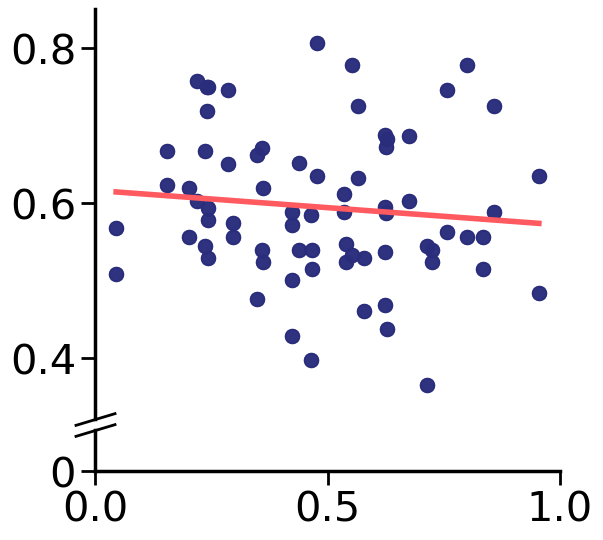

Path
Mean RMSE: 0.0920 $\pm$ 0.00422
n=360
Feature 0 corr=-0.251, $p$=0.00000


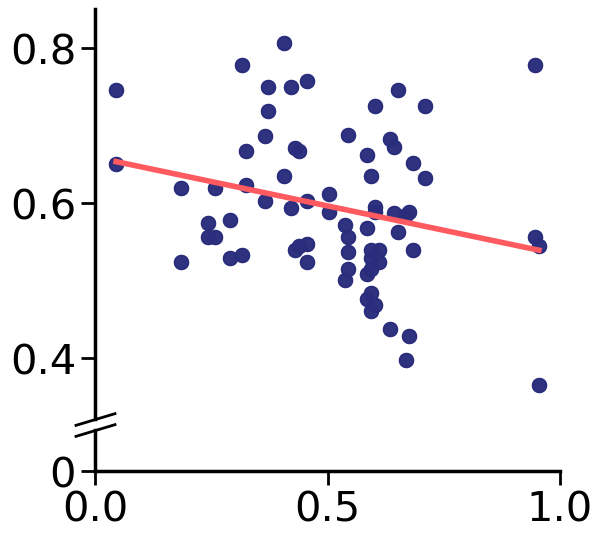

avg_dist travelled
Mean RMSE: 0.0921 $\pm$ 0.00511
n=360
Feature 0 corr=-0.239, $p$=0.00000


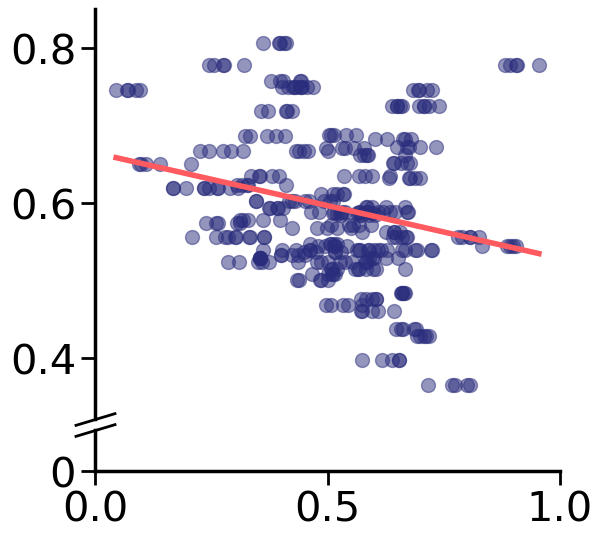

avg_nodes_count
Mean RMSE: 0.0892 $\pm$ 0.00534
n=360
Feature 0 corr=-0.339, $p$=0.00000


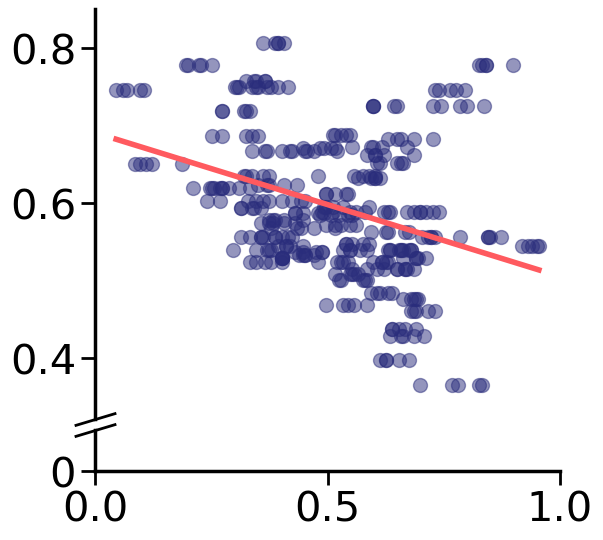

avg_turns_count
Mean RMSE: 0.0905 $\pm$ 0.00755
n=360
Feature 0 corr=-0.291, $p$=0.00000


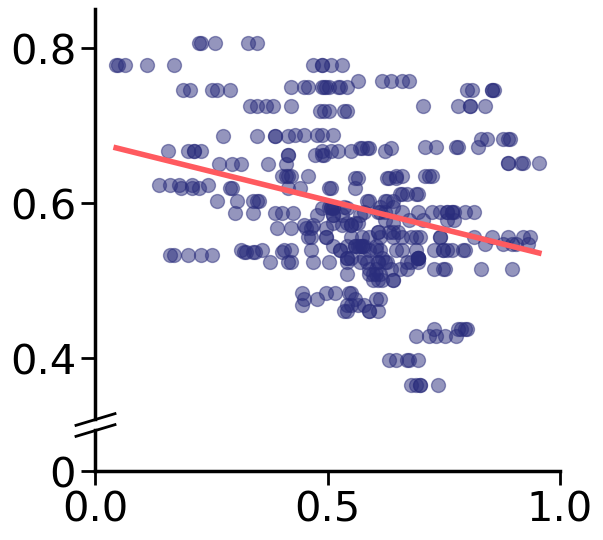

In [293]:
# norm static features
normed_static_features = np.ones_like(static_features)
for i in range(static_features.shape[1]):
    normed = static_features[:,i]
    min_val, max_val = normed.min(), normed.max()
    normed = (normed - min_val) / (max_val - min_val)

    normed_static_features[:,i] = normed
    
print("Euclid")
run_evaluate_regression(normed_static_features[:,0].reshape(-1, 1), accuracies, feature_str="euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count", axes=["", "", ""], y_axis=True)

print("Path")
run_evaluate_regression(normed_static_features[:,1].reshape(-1, 1), accuracies, feature_str="euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count", axes=["", "", ""])

print("avg_dist travelled")
run_evaluate_regression(normed_static_features[:,3].reshape(-1, 1), accuracies, feature_str="euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count", axes=["", "", ""], y_axis=True)

print("avg_nodes_count")
run_evaluate_regression(normed_static_features[:,-2].reshape(-1, 1), accuracies, feature_str="euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count", axes=["", "", ""], y_axis=False)

print("avg_turns_count")
run_evaluate_regression(normed_static_features[:,-1].reshape(-1, 1), accuracies, feature_str="euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count", axes=["", "", ""])

# print("all static")
# run_evaluate_regression(normed_static_features, accuracies, feature_str="euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count", axes=["", "", ""])

#### Tree features & embeddings

num_nodes
Mean RMSE: 0.0681 $\pm$ 0.00463
n=360
Feature 0 corr=-0.694, $p$=0.00000


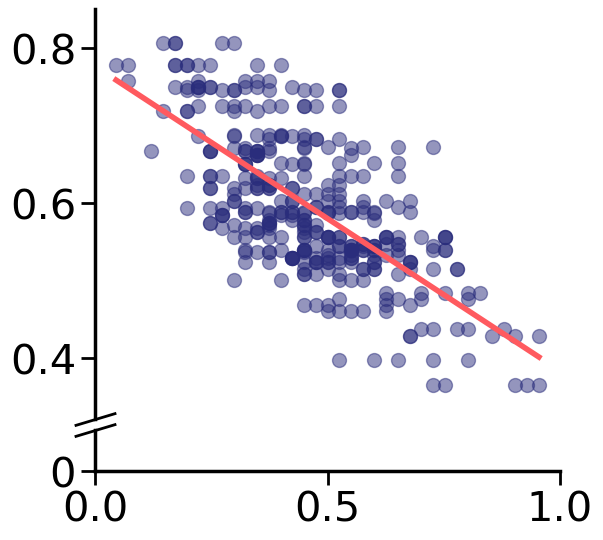

depth
Mean RMSE: 0.0867 $\pm$ 0.00434
n=360
Feature 0 corr=-0.409, $p$=0.00000


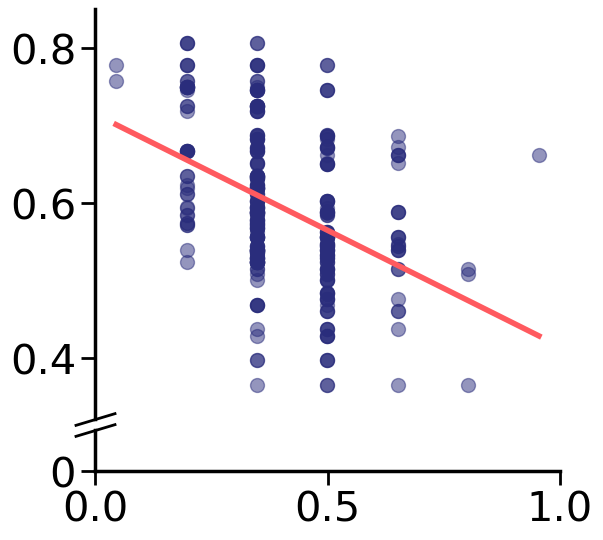

avg_branching_factor
Mean RMSE: 0.0712 $\pm$ 0.00258
n=360
Feature 0 corr=-0.658, $p$=0.00000


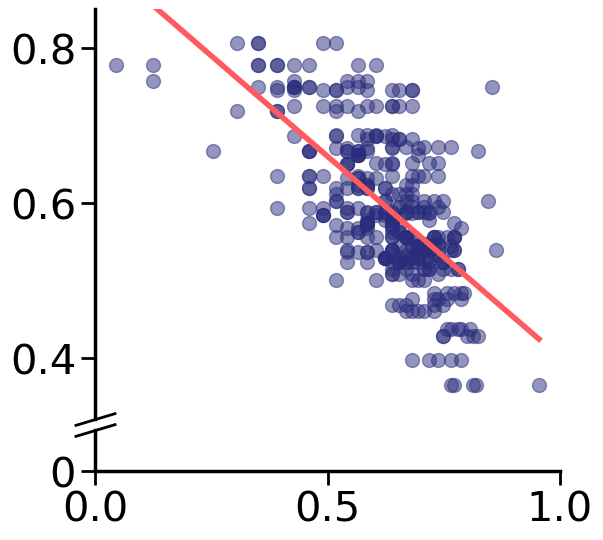

backbone_thickness
Mean RMSE: 0.0857 $\pm$ 0.00404
n=360
Feature 0 corr=0.423, $p$=0.00000


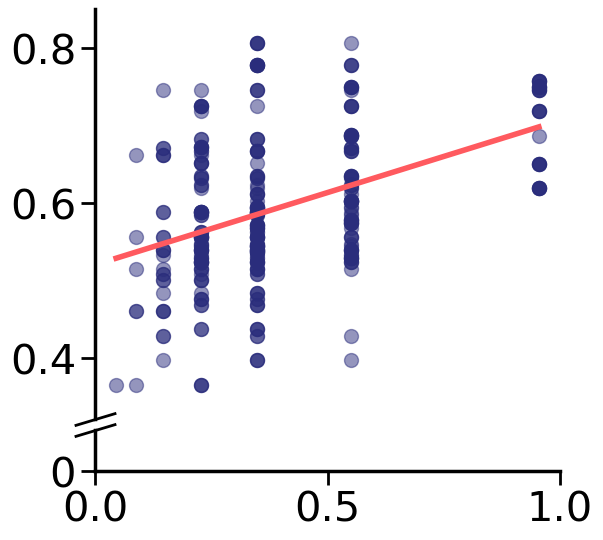

diameter
Mean RMSE: 0.0805 $\pm$ 0.00395
n=360
Feature 0 corr=-0.526, $p$=0.00000


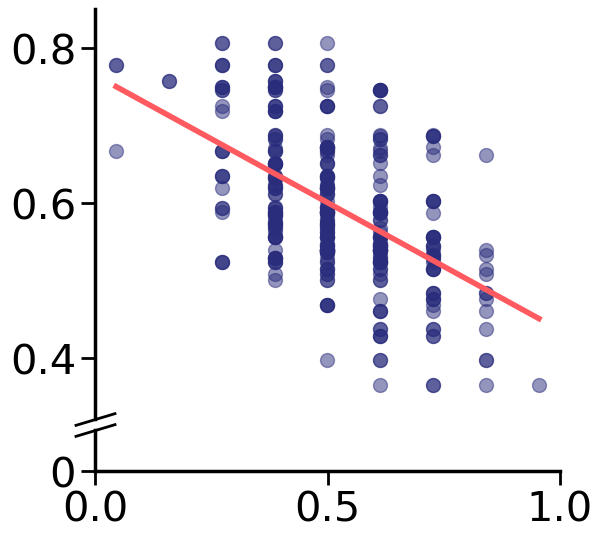

num_leaves
Mean RMSE: 0.0676 $\pm$ 0.00529
n=360
Feature 0 corr=-0.699, $p$=0.00000


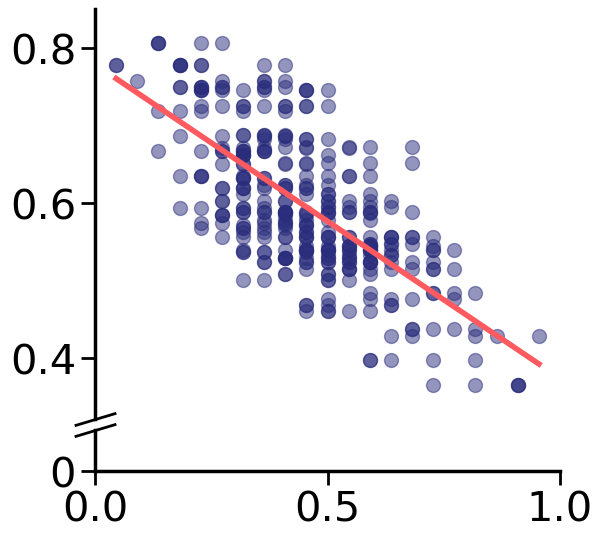

In [294]:
# norm features
normed_flow_tree_features = np.ones_like(flow_tree_features)
for i in range(flow_tree_features.shape[1]):
    normed = flow_tree_features[:,i]
    min_val, max_val = normed.min(), normed.max()
    normed = (normed - min_val) / (max_val - min_val)

    normed_flow_tree_features[:,i] = normed
    
# Flow Tree
print("num_nodes")
run_evaluate_regression(normed_flow_tree_features[:,0].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""], y_axis=True)

print("depth")
run_evaluate_regression(flow_tree_features[:,1].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("avg_branching_factor")
run_evaluate_regression(flow_tree_features[:,-2].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("backbone_thickness")
run_evaluate_regression(flow_tree_features[:,-1].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("diameter")
run_evaluate_regression(flow_tree_features[:,2].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("num_leaves")
run_evaluate_regression(flow_tree_features[:,3].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

# print("all flow tree")
# run_evaluate_regression(normed_flow_tree_features, accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])


# print("embeddings")
# # run_evaluate_regression(flow_tree_diameters, accuracies, feature_str="diameter", axes=["", "", ""])
# run_evaluate_regression(reduced_features[:,0].reshape(-1, 1), accuracies, feature_str="pca1,pca2", axes=["", "", ""])
# run_evaluate_regression(reduced_features[:,-1].reshape(-1, 1), accuracies, feature_str="pca1,pca2", axes=["", "", ""])

### Compare regressions w/ Fisher r to z

In [119]:
def compare_correlations(r1, n1, r2, n2):
    z1 = 0.5 * np.log((1 + r1) / (1 - r1))
    z2 = 0.5 * np.log((1 + r2) / (1 - r2))
    
    std_error = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    
    # z-score
    z = (z1 - z2) / std_error
    p = 2 * (1 - norm.cdf(abs(z)))  # two-tailed test

    return z, p

def steiger_z_test(r12, r13, r23, n, alternative="two-sided"):
    # Steiger's Z formula for comparing two dependent correlations
    # compares corr 1-2 vs. corr 1-3

    if n < 4:
        raise ValueError("Sample size must be at least 4")

    z_num = (r12 - r13) * np.sqrt((n - 3) * (1 + r23))
    z_denom = 2 * (1 - r12**2 - r13**2 - r23**2 + 2 * r12 * r13 * r23)
    z_denom = np.sqrt(z_denom)

    if z_denom == 0:
        raise ValueError("Denominator is zero — check your correlations.")

    z = z_num / z_denom

    # Choose p-value based on test direction
    if alternative == 'two-sided':
        p = 2 * (1 - norm.cdf(abs(z)))
    elif alternative == 'greater':  # r12 > r13
        p = 1 - norm.cdf(z)
    elif alternative == 'less':     # r12 < r13
        p = norm.cdf(z)
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

    return z, p

static_feature_names = ["euclid", "minpath", "_", "disttrav", "nodestrav", "turnstaken"]
ft_feature_names = ["num_nodes", "depth", "diameter", "num_leaves", "avg_branching_factor", "backbone_thickness"]


best_static_struct = "minpath"
best_static_nav = "nodestrav"

for j, static_feat_name in enumerate(static_feature_names):
    if static_feat_name not in ("minpath", "nodestrav"): continue

    print(f"Compare with {static_feat_name}, best structural:")
    x2 = normed_static_features[:, j]

    for i, ft_feat_name in enumerate(ft_feature_names):
        x3 = normed_flow_tree_features[:, i]
        
        r12, _ = pearsonr(accuracies, x2)
        r13, _ = pearsonr(accuracies, x3)
        r23, _ = pearsonr(x2, x3)

        # Testing: is r12 > r13? (i.e. is x2 more correlated with accuracies than x3?)
        z, p = steiger_z_test(r12, r13, r23, n=len(accuracies), alternative="greater")
        print(f"\t{ft_feat_name}: Z={z:0.5f}, p={p:0.5f}")

    print()
    for i, ft_feat_name in enumerate(static_feature_names):
        x3 = normed_static_features[:, i]
        
        r12, _ = pearsonr(accuracies, x2)
        r13, _ = pearsonr(accuracies, x3)
        r23, _ = pearsonr(x2, x3)

        # Testing: is r12 > r13? (i.e. is x2 more correlated with accuracies than x3?)
        z, p = steiger_z_test(r12, r13, r23, n=len(accuracies), alternative="greater")
        print(f"\t{ft_feat_name}: Z={z:0.5f}, p={p:0.5f}")
    print()


Compare with minpath, best structural:
	num_nodes: Z=10.74099, p=0.00000
	depth: Z=2.69039, p=0.00357
	diameter: Z=5.46597, p=0.00000
	num_leaves: Z=10.77647, p=0.00000
	avg_branching_factor: Z=8.97491, p=0.00000
	backbone_thickness: Z=-7.96607, p=1.00000

	euclid: Z=-3.04709, p=0.99884
	minpath: Z=0.00000, p=0.50000
	_: Z=4.03526, p=0.00003
	disttrav: Z=-0.71983, p=0.76419
	nodestrav: Z=3.61973, p=0.00015
	turnstaken: Z=0.74690, p=0.22756

Compare with nodestrav, best structural:
	num_nodes: Z=9.92510, p=0.00000
	depth: Z=1.30421, p=0.09608
	diameter: Z=4.12970, p=0.00002
	num_leaves: Z=9.87465, p=0.00000
	avg_branching_factor: Z=8.07683, p=0.00000
	backbone_thickness: Z=-8.81447, p=1.00000

	euclid: Z=-5.23798, p=1.00000
	minpath: Z=-3.61973, p=0.99985
	_: Z=-0.21168, p=0.58382
	disttrav: Z=-5.82215, p=1.00000
	nodestrav: Z=nan, p=nan
	turnstaken: Z=-1.09700, p=0.86368



### Heatmaps

(360, 25)
(360,)
heatmaps
Mean RMSE: 0.06595852201019935
Standard Deviation of RMSE: 0.00553883936690535
Linear Regression Coefficients: [0.02104372 0.12088961 0.03520544 0.12908712 0.02521061 0.03903115
 0.07589386 0.0693845  0.08443624 0.01633296 0.09736949 0.01686585
 0.18562085 0.12200932 0.07071393 0.06291662 0.16906774 0.08297945
 0.02528828 0.08183787 0.09769148 0.16723434 0.04343196 0.25146299
 0.12022683]
A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z
Intercept: 1.20
R-squared: 0.57
Feature 23 corr=-0.371, p=0.00000
0.25 X regression line
Feature 12 corr=-0.028, p=0.59193
0.19 M regression line
Feature 16 corr=-0.412, p=0.00000
0.17 Q regression line


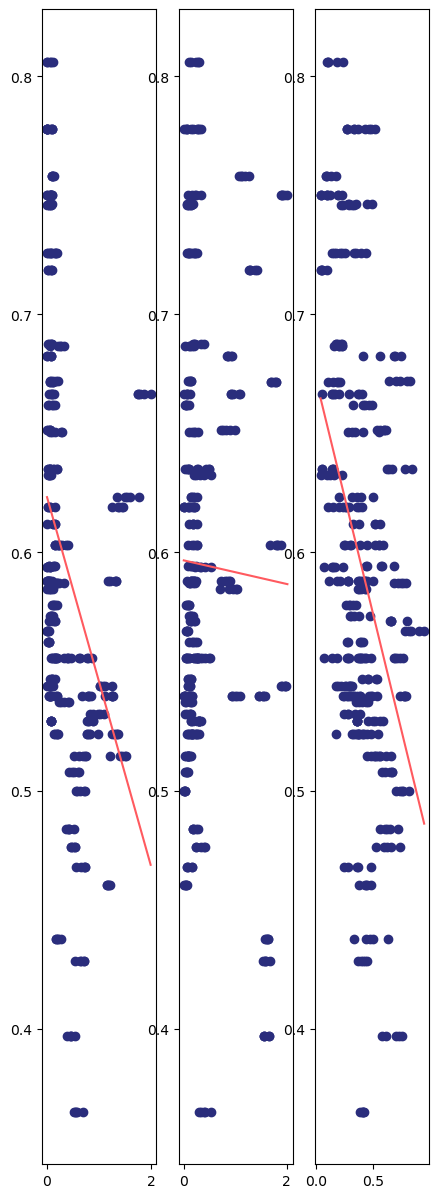

In [87]:
def letter_counts(strings):
    # Create a numpy array of zeros for 26 letters (A-Z)
    counts = np.zeros(26, dtype=int)
    
    # Loop through each string in the list
    for string in strings:
        for char in string:
            if 'A' <= char <= 'Z':  # Only consider capital letters
                index = ord(char) - ord('A')  # Convert letter to its corresponding index (A=0, B=1, ..., Z=25)
                counts[index] += 1

    return counts
    
## Heatmap features
heatmap_features = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    acc = group["path_mean_acc"].iloc[0]

    if len(group) < min_sample_size: 
        print("AJ")
        continue

    hmfts = []

    # sample 5 times for each flow tree
    for i in range(5):
        
        sample_df1 = group.sample(n=min_sample_size, random_state=i, replace=False) 


        str_counts = np.zeros(26)
        for string in sample_df1["paths"]:
            for char in string:
                if 'A' <= char <= 'Z':
                    index = ord(char) - ord('A')  # Convert letter to its corresponding index (A=0, B=1, ..., Z=25)
                    str_counts[index] += 1
        str_counts /= np.sum(str_counts) 
        str_counts *= 10
        heatmap_features.append(str_counts)

# doing y and z makes everything horrible and crazy...
heatmap_features = np.array(heatmap_features)[:, :25]

print(heatmap_features.shape)
print(accuracies.shape)
print("heatmaps")
run_evaluate_regression(heatmap_features, accuracies, feature_str=",".join([x for x in "ABCDEFGHIJKLMNOPQRSTUVWXYZ"]), axes=["", "", ""])


## 6. Backbone thickness

Correlation between backbone thickness and accuracy: 0.423
P-value: 0.000


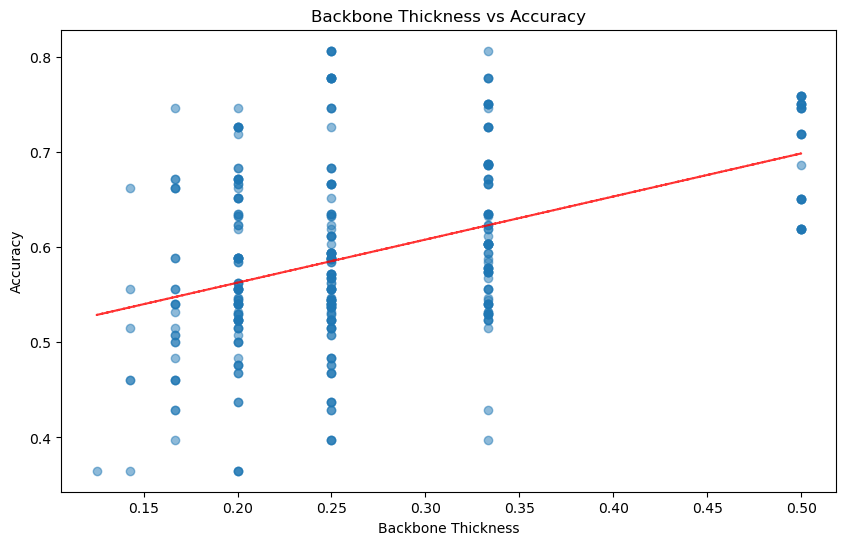

In [61]:
# Extract backbone thickness (last feature)
backbone_thickness = flow_tree_features[:, -1]

# Calculate correlation coefficient and p-value
correlation, p_value = pearsonr(backbone_thickness, accuracies)

print(f"Correlation between backbone thickness and accuracy: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(backbone_thickness, accuracies, alpha=0.5)
plt.xlabel('Backbone Thickness')
plt.ylabel('Accuracy')
plt.title('Backbone Thickness vs Accuracy')

# Add trend line
z = np.polyfit(backbone_thickness, accuracies, 1)
p = np.poly1d(z)
plt.plot(backbone_thickness, p(backbone_thickness), "r--", alpha=0.8)

plt.show()


## 7. Miscellaneous Archives

### Compare winners to losers

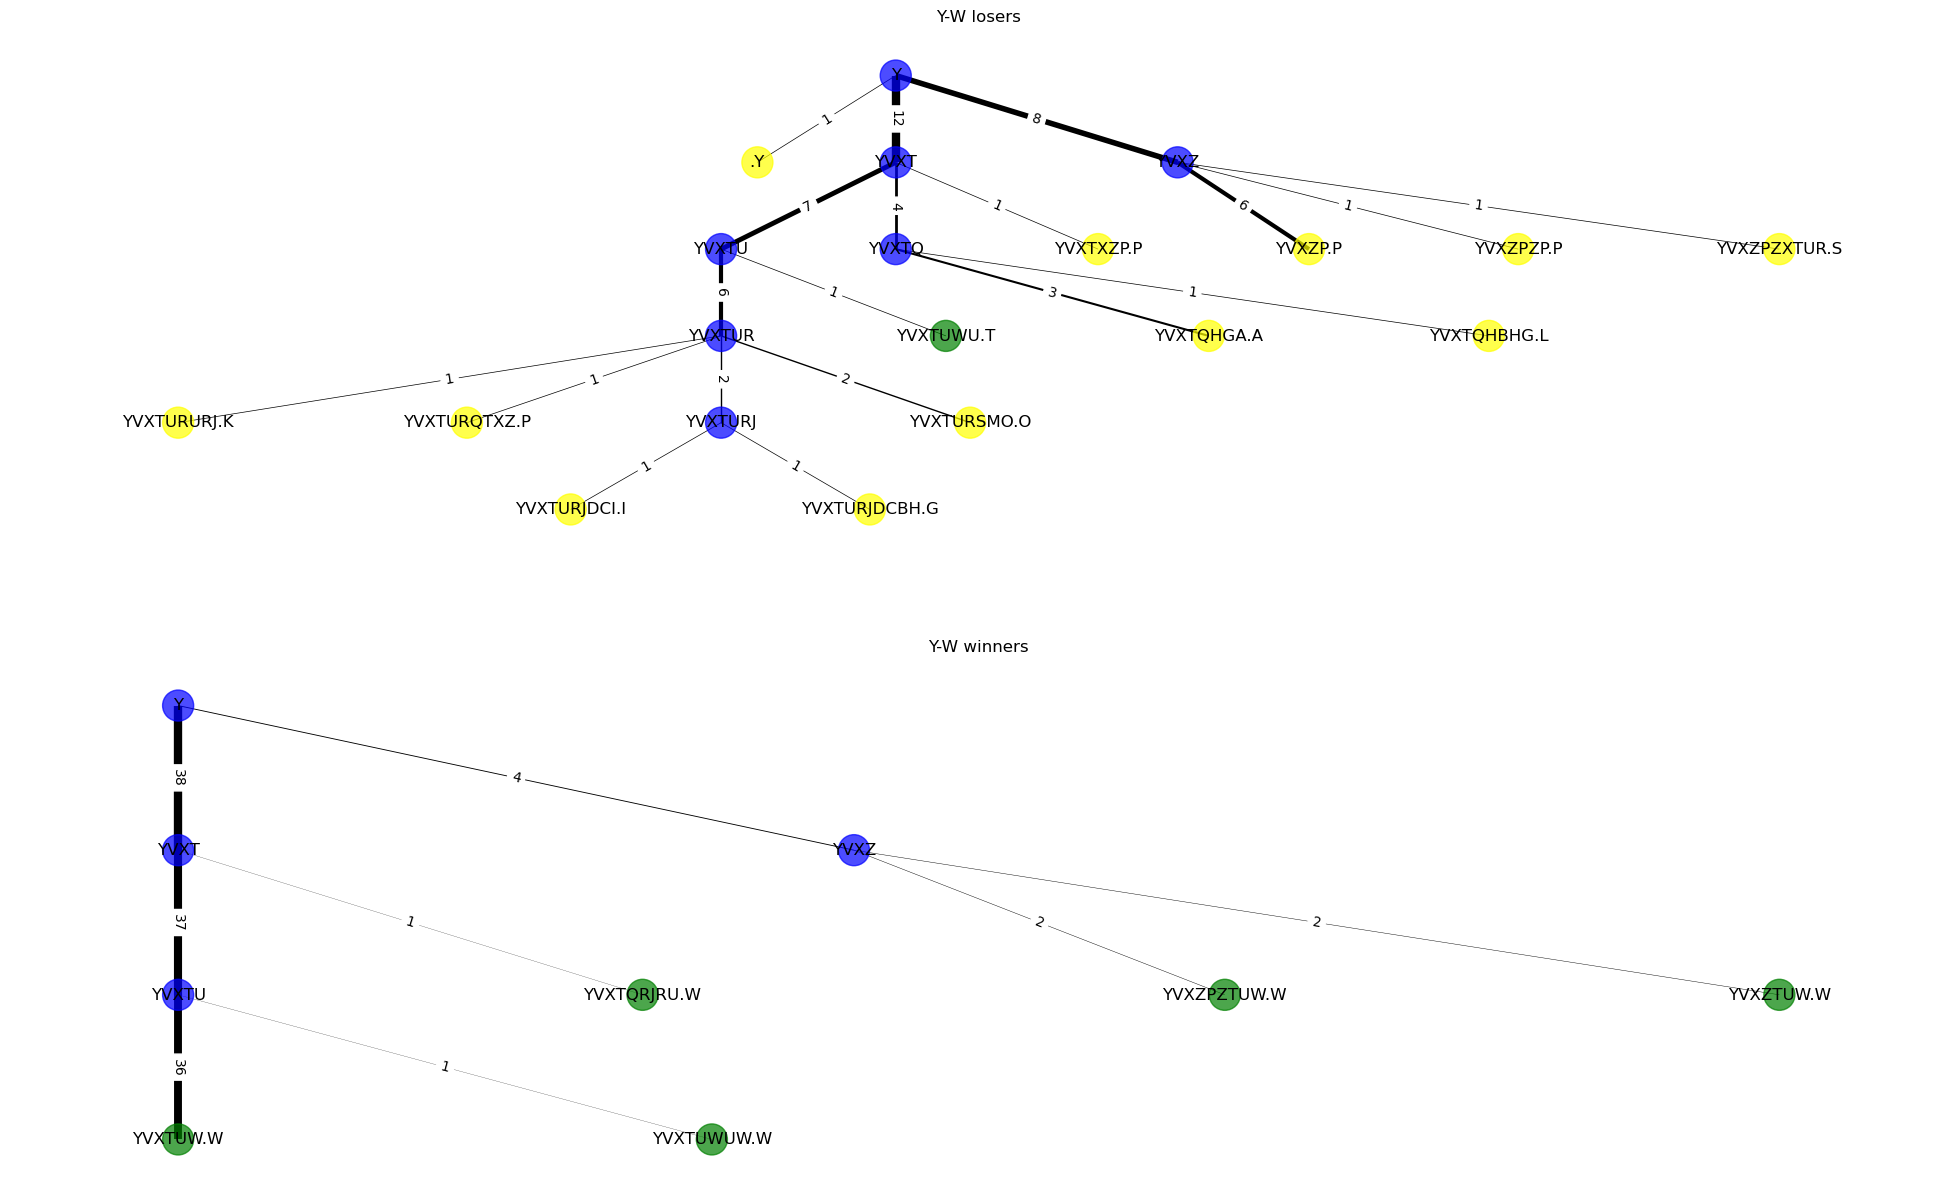

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(25,15))

nodea, nodeb = "Y", "W"

G = loser_tree_dict[(nodea, nodeb)]
plot_flow_tree(G, f"{nodea}-{nodeb} losers", axes[0])

G = winner_tree_dict[(nodea, nodeb)]
plot_flow_tree(G, f"{nodea}-{nodeb} winners", axes[1])

plt.show()

#### Plot by pairs

In [63]:
OBJECTS = "AIKLNOPWY"

acc_diffs = []
obj_pairs = []
for i in range(len(OBJECTS) - 1):
    for j in range(i+1, len(OBJECTS)):
        object_a, object_b = OBJECTS[i], OBJECTS[j] 

        acc_diffs.append(np.abs(tree_dict[(object_a, object_b)][1] - tree_dict[(object_b, object_a)][1]))
        obj_pairs.append((object_a, object_b))
        

# Uncomment to plot all pairs
# sorted_order = [x for x in sorted(range(len(acc_diffs)), key=lambda x: acc_diffs[x])]
# for i, tree_index in enumerate(sorted_order):
#     object_a, object_b = obj_pairs[tree_index]
    
#     fig, axes = plt.subplots(2, 3, figsize=(20,10))

#     G, acc = tree_dict[(object_a, object_b)]
#     plot_flow_tree(G, f"{object_a}-{object_b} {acc:.2f}", axes[0][0], just_edges=True)

#     G, acc = tree_dict[(object_b, object_a)]
#     plot_flow_tree(G, f"{object_b}-{object_a} {acc:.2f}", axes[1][0], just_edges=True)

#     G = winner_tree_dict[(object_a, object_b)]
#     plot_flow_tree(G, f"winners {object_a}-{object_b}", axes[0][1], just_edges=True)

#     G = winner_tree_dict[(object_b, object_a)]
#     plot_flow_tree(G, f"winners {object_b}-{object_a}", axes[1][1], just_edges=True)

#     G = loser_tree_dict[(object_a, object_b)]
#     plot_flow_tree(G, f"losers {object_a}-{object_b}", axes[0][2], just_edges=True)

#     G = loser_tree_dict[(object_b, object_a)]
#     plot_flow_tree(G, f"losers {object_b}-{object_a}", axes[1][2], just_edges=True)

#     fig.suptitle(f"ACC DIFFERENCE {acc_diffs[tree_index]:.2f}")

#     fig.savefig(f"figures/pairs/flow_tree_{object_a}-{object_b}.png")

#     plt.show()

### Questions from some point


1. Is palindrome more common among winners than losers?? Is it predictive of success?
2. Did anyone who got it right go into an object?
3. Maybe the people who got it wrong did?
4. Look for particular foil? Will all losers end up at the same wrong place? What are the most common foils?? Is there systematic? Why are there consistent wrong places?
5. Do they get it wrong bc they end up at same place bc they take paths that get them to the wrong spot?
6. Are entropy of leaves and entropy of tree correlated? Especially for losers


#### Palindromes

Winners w/ palindrome: total=212 mean=0.08
Losers w/ palindrome: total=616 mean=0.33


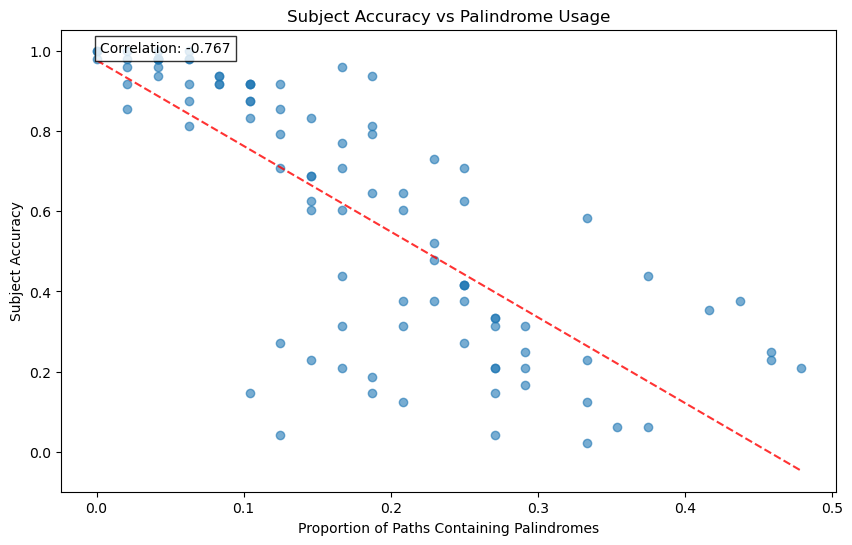

In [64]:
def contains_palindrome(traj):
    for i in range(len(traj)-2):
        if traj[i] == traj[i+2]:
            return True
    return False

winner_palindromes = []
loser_palindromes = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    accs = np.array(group["accuracy"])
    
    for traj, acc in zip(trajs, accs):
        if acc:
            winner_palindromes.append(contains_palindrome(traj))
        else:
            loser_palindromes.append(contains_palindrome(traj))
    
print(f"Winners w/ palindrome: total={np.sum(winner_palindromes)} mean={np.mean(winner_palindromes):.2f}")
print(f"Losers w/ palindrome: total={np.sum(loser_palindromes)} mean={np.mean(loser_palindromes):.2f}")

# Group by subject and calculate palindrome ratio and accuracy
subject_stats = []
for subject, group in test_df.groupby("Subject"):
    trajs = generate_trajs_from_df(group)
    palindrome_ratio = np.mean([contains_palindrome(traj) for traj in trajs])
    accuracy = np.mean(group["accuracy"])
    subject_stats.append({
        "subject": subject,
        "palindrome_ratio": palindrome_ratio,
        "accuracy": accuracy
    })

# Convert to DataFrame for plotting
stats_df = pd.DataFrame(subject_stats)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(stats_df["palindrome_ratio"], stats_df["accuracy"], alpha=0.6)
plt.xlabel("Proportion of Paths Containing Palindromes")
plt.ylabel("Subject Accuracy")
plt.title("Subject Accuracy vs Palindrome Usage")

# Add trend line
z = np.polyfit(stats_df["palindrome_ratio"], stats_df["accuracy"], 1)
p = np.poly1d(z)
x_trend = np.linspace(stats_df["palindrome_ratio"].min(), stats_df["palindrome_ratio"].max(), 100)
plt.plot(x_trend, p(x_trend), "r--", alpha=0.8)

# Calculate and display correlation
correlation = stats_df["palindrome_ratio"].corr(stats_df["accuracy"])
plt.text(0.05, 0.95, f"Correlation: {correlation:.3f}", 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

#### Tree and leaf entropy

In [65]:
# Calculate entropy for winner/loser trees and final nodes

# Helper function to calculate entropy
def calculate_entropy(counts):
    probabilities = counts / np.sum(counts)
    # Remove zero probabilities to avoid log(0)
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))

def calculate_tree_entropy(G):
    # Get all non-leaf nodes (nodes with outgoing edges)
    non_leaf_nodes = [node for node in G.nodes() if len(list(G.neighbors(node))) > 0]
    
    tree_entropy = 0
    for node in non_leaf_nodes:
        # Get outgoing edges and their weights
        edge_weights = [G.edges[node, successor]['weight'] for successor in G.neighbors(node)]
        total_weight = sum(edge_weights)
        
        if total_weight > 0:  # Avoid division by zero
            # Calculate probabilities for each branch
            probabilities = np.array(edge_weights) / total_weight
            
            # Calculate entropy for this node
            node_entropy = -np.sum(probabilities * np.log2(probabilities))
            tree_entropy += node_entropy
    
    return tree_entropy

# Calculate entropy for winner/loser trees
winner_tree_entropies = []
loser_tree_entropies = []

winner_leaf_entropies = []
loser_leaf_entropies = []

accs = []

pairs = []

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    pairs.append(start_node+end_node)
    trajs = generate_trajs_from_df(group)
    # G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    # new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    # flow_trees.append(new_G)
    accs.append(group["path_mean_acc"].iloc[0])
    # paths.append((start_node, end_node))
    # tree_dict[(start_node, end_node)] = [new_G, group["path_mean_acc"].iloc[0]]

    group["accuracy"] = group["accuracy"].astype(bool)

    # WINNERS ONLY
    winner_trajs = generate_trajs_from_df(group[group["accuracy"]])
    winner_ends = [winner_traj[-1] for winner_traj in winner_trajs]
    winner_end_counts = pd.Series(winner_ends).value_counts()
    winner_leaf_entropies.append(calculate_entropy(winner_end_counts))

    G_winner = generate_flow_tree_from_trajs(winner_trajs, END_NODE=end_node)
    winner_tree_entropies.append(calculate_tree_entropy(G_winner))

    # G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    # winner_tree_dict[(start_node, end_node)] = G

    # LOSERS ONLY
    loser_trajs = generate_trajs_from_df(group[~group["accuracy"]])
    loser_ends = [loser_traj[-1] for loser_traj in loser_trajs]
    loser_end_counts = pd.Series(loser_ends).value_counts()
    loser_leaf_entropies.append(calculate_entropy(loser_end_counts))

    G_loser = generate_flow_tree_from_trajs(loser_trajs, END_NODE=end_node)
    loser_tree_entropies.append(calculate_tree_entropy(G_loser))

    # G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    # loser_tree_dict[(start_node, end_node)] = G

# Print mean and variance of leaf entropies
print(f"Winner leaf entropy - Mean: {np.mean(winner_leaf_entropies):.3f}, Variance: {np.var(winner_leaf_entropies):.3f}")
print(f"Loser leaf entropy - Mean: {np.mean(loser_leaf_entropies):.3f}, Variance: {np.var(loser_leaf_entropies):.3f}")
print("Entropy of 3 can mean there are 2^3 equally likely outcomes.")

print(f"Winner tree entropy - Mean: {np.mean(winner_tree_entropies):.3f}, Variance: {np.var(winner_tree_entropies):.3f}")
print(f"Loser tree entropy - Mean: {np.mean(loser_tree_entropies):.3f}, Variance: {np.var(loser_tree_entropies):.3f}")


import plotly.express as px
import plotly.graph_objects as go

# Create a dataframe for plotly
df = pd.DataFrame({
    'Leaf Entropy': loser_leaf_entropies,
    'Tree Entropy': loser_tree_entropies,
    'Winner Tree Entropy': winner_tree_entropies,
    'Mean Accuracy': accs,
    'Pair': pairs
})

# Create scatter plot
fig = px.scatter(df, 
                 x='Leaf Entropy', 
                 y='Tree Entropy',
                 color='Mean Accuracy',
                 hover_data={'Leaf Entropy': ':.3f',
                           'Tree Entropy': ':.3f', 
                           'Winner Tree Entropy': ':.3f',
                           'Mean Accuracy': ':.3f',
                           'Pair': True},
                 opacity=1,
                 color_continuous_scale='viridis',
                 title='Loser Leaf Entropy vs Tree Entropy')

# Add diagonal reference line
fig.add_trace(
    go.Scatter(x=[min(loser_leaf_entropies), max(loser_leaf_entropies)],
               y=[min(loser_leaf_entropies), max(loser_leaf_entropies)],
               mode='lines',
               line=dict(dash='dash', color='black', width=1),
               opacity=0.3,
               showlegend=False)
)

# Update layout
fig.update_layout(
    width=1000,
    height=600,
    xaxis_title="Loser Leaf Entropy",
    yaxis_title="Loser Tree Entropy",
    xaxis=dict(range=[min(loser_leaf_entropies), max(loser_leaf_entropies)]),
    coloraxis_colorbar_title="Mean Path Accuracy"
)

fig.show()


Winner leaf entropy - Mean: 0.000, Variance: 0.000
Loser leaf entropy - Mean: 3.438, Variance: 0.097
Entropy of 3 can mean there are 2^3 equally likely outcomes.
Winner tree entropy - Mean: 5.311, Variance: 7.317
Loser tree entropy - Mean: 22.703, Variance: 43.370


#### Backbones

In [66]:
def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    # leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]
    
    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

flow_tree_dict = {}
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    # print("Finding backbone for", path)
    backbone_path, max_weight, weights = get_heaviest_path(G, start_node)
    flow_tree_dict[(start_node, end_node)] = {
        "flow_tree": G,
        "acc": group["path_mean_acc"].iloc[0],
        "backbone_path": backbone_path,
        "backbone_weights": weights
        }

#### Look for left v right paths

In [67]:
def simplify_path_frl(path):
    nodes_visited = path.split()[:-1]
    
    simplified = ""
    for i in range(len(nodes_visited)-1):
        rt = {1:2, 2:3, 3:4, 4:1}
        lt = {2:1, 1:4, 4:3, 3:2}

        curr_node, next_node = nodes_visited[i], nodes_visited[i+1]
        if curr_node[0] != next_node[0]:
            # forward press
            simplified += "F"
        elif rt[int(curr_node[1])] == int(next_node[1]):
            # right turn
            simplified += "R"
        elif lt[int(curr_node[1])] == int(next_node[1]):
            # left turn
            simplified += "L"
        else:
            # print(curr_node, next_node)
            simplified += "R"
            ## N3 N1 spin
            # print("FUCK ME")
        
    return simplified

# Get R and L counts for each start-end pair
backbone_R_counts = []
backbone_L_counts = []
backbone_RL_ratios = []
R_counts = []
L_counts = []
RL_ratios = []
labels = []
accs = []
overall_RL_labels = {}

racc = []
lacc = []
facc = []

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    accs.append(group["path_mean_acc"].iloc[0])
    paths.append((start_node, end_node))
    
    winner_group = group[group["accuracy"]]
    frl_paths = winner_group["e_paths"].apply(simplify_path_frl)
    R_count = frl_paths.str.count("R").sum()
    L_count = frl_paths.str.count("L").sum()
    F_count = frl_paths.str.count("F").sum()
    total = R_count + L_count + F_count
    
    R_counts.append(R_count/total)
    L_counts.append(L_count/total)
    RL_ratios.append(R_count/L_count)
    labels.append(f"{start_node}->{end_node}")

    backbone_path = flow_tree_dict[(start_node, end_node)]["backbone_path"][-1]
    winner_trajs = generate_trajs_from_df(winner_group)
    winner_used_backbone = [backbone_path == "".join(traj) for traj in winner_trajs]

    backbone_indices = [i for i, used_backbone in enumerate(winner_used_backbone) if used_backbone]
    backbone_e_paths = winner_group["e_paths"].iloc[backbone_indices]
    backbone_frl_paths = backbone_e_paths.apply(simplify_path_frl)

    backbone_R_count = backbone_frl_paths.str.count("R").sum()
    backbone_L_count = backbone_frl_paths.str.count("L").sum()
    backbone_F_count = backbone_frl_paths.str.count("F").sum()
    backbone_total = backbone_R_count + backbone_L_count + backbone_F_count
    
    backbone_R_counts.append(backbone_R_count/backbone_total)
    backbone_L_counts.append(backbone_L_count/backbone_total)
    backbone_RL_ratios.append(backbone_R_count/backbone_L_count)


    gamma = 0.25
    if backbone_R_count/backbone_L_count > 1+gamma:
        RLF_label = "R"
        racc.append(group["path_mean_acc"].iloc[0])
    elif backbone_R_count/backbone_L_count < 1-gamma:
        RLF_label = "L"
        lacc.append(group["path_mean_acc"].iloc[0])
    else:
        RLF_label = "F"
        facc.append(group["path_mean_acc"].iloc[0])

    overall_RL_labels[(start_node, end_node)] = RLF_label
    
# Create scatter plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=R_counts,
    y=L_counts,
    mode='markers+text',
    text=labels,
    textposition="top center",
    marker=dict(
        color=accs,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Accuracy")
    ),
    hovertemplate="R_counts: %{x}<br>L_counts: %{y}<br>Path: %{text}<br>Accuracy: %{marker.color:.2f}<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=[0, 0.5],
    y=[0, 0.5],
    mode='lines',
    line=dict(dash='dot', color='gray'),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[0, 0.5 /(1+gamma)],
    y=[0, 0.5],
    mode='lines',
    line=dict(dash='dot', color='gray'),
    showlegend=False
))


fig.add_trace(go.Scatter(
    x=[0, 0.5],
    y=[0, 0.5 /(1+gamma)],
    mode='lines',
    line=dict(dash='dot', color='gray'),
    showlegend=False
))

fig.update_layout(
    width=1200,
    height=800,
    xaxis_title="R Ratio",
    yaxis_title="L Ratio",
    title="L v R ratio in Successful Paths",
)

fig.show()


In [68]:
# Create scatter plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=backbone_RL_ratios,
    y=accs,
    mode='markers+text',
    text=labels,
    textposition="top center",
    marker=dict(
        color=accs,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Accuracy")
    ),
    hovertemplate="RL ratios: %{x}<br>Accuracy: %{y}<br>Path: %{text}<br>Accuracy: %{marker.color:.2f}<extra></extra>"
))


fig.update_layout(
    width=800,
    height=600,
    xaxis_type="log",
    xaxis_title="RL Ratio",
    yaxis_title="Accuracy",
    title="RL ratio v Accuracy in Successful Paths",
)

fig.show()

from scipy import stats

backbone_RL_ratios = np.array(backbone_RL_ratios)
accs = np.array(accs)

valid_indices = ~(np.isnan(backbone_RL_ratios) | np.isinf(backbone_RL_ratios) | np.isnan(accs) | np.isinf(accs))


# Calculate correlation coefficient between backbone RL ratios and accuracy
correlation = np.corrcoef(backbone_RL_ratios[valid_indices], accs[valid_indices])[0,1]
print(f"Correlation coefficient between backbone R/L ratio and accuracy: {correlation:.3f}")


stat, p_value = stats.pearsonr(backbone_RL_ratios[valid_indices], accs[valid_indices])
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("The correlation is statistically significant (p < 0.05)")
else:
    print("The correlation is not statistically significant (p >= 0.05)")


Correlation coefficient between backbone R/L ratio and accuracy: 0.161
P-value: 0.180
The correlation is not statistically significant (p >= 0.05)


In [69]:
# Create scatter plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=RL_ratios,
    y=backbone_RL_ratios,
    mode='markers+text',
    text=labels,
    textposition="top center",
    marker=dict(
        color=accs,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Accuracy")
    ),
    hovertemplate="R/L Ratio: %{x}<br>R/L ratio bacbone: %{y}<br>Path: %{text}<br>Accuracy: %{marker.color:.2f}<extra></extra>"
))

# Add reference lines
fig.add_trace(go.Scatter(
    x=[0.1, 10],
    y=[0.5, 0.5],
    mode='lines',
    line=dict(dash='dot', color='gray'),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[0.5, 0.5],
    y=[0.1, 10],
    mode='lines', 
    line=dict(dash='dot', color='gray'),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[0.1, 10],
    y=[0.1, 10],
    mode='lines',
    line=dict(dash='dot', color='gray'),
    showlegend=False
))

fig.update_layout(
    width=1200,
    height=800,
    xaxis_title="R/L Ratio",
    yaxis_title="R/L Ratio Backbone",
    title="R/L Ratio in backbone v overall in Successful Paths",
    xaxis_type="log",
    yaxis_type="log",
    xaxis=dict(range=[-1, 1]), # 10^-1 to 10^1
    yaxis=dict(range=[-1, 1])
)

fig.show()

In [70]:
# Determine groups
print(overall_RL_labels)

print(len(racc), len(lacc), len(facc))



# Create violin plots for R/L/F accuracies
fig = go.Figure()

# Add violin plots for each direction
fig.add_trace(go.Violin(
    y=racc,
    name='Right',
    box_visible=True,
    meanline_visible=True
))

fig.add_trace(go.Violin(
    y=lacc, 
    name='Left',
    box_visible=True,
    meanline_visible=True
))

fig.add_trace(go.Violin(
    y=facc,
    name='Forward',
    box_visible=True,
    meanline_visible=True
))

fig.update_layout(
    title='Distribution of Accuracies by Direction',
    yaxis_title='Accuracy',
    width=1000,
    height=600,
    showlegend=True
)

fig.show()

# Create a heatmap showing R/L/F distribution by start/end nodes
start_nodes = sorted(list(set(test_df['StartAt'])))
end_nodes = sorted(list(set(test_df['EndAt'])))

# Create matrix to store R/L/F values
direction_matrix = np.empty((len(start_nodes), len(end_nodes)), dtype='object')

# Fill matrix with predominant direction for each start-end pair
for i, start in enumerate(start_nodes):
    for j, end in enumerate(end_nodes):

        direction_matrix[i,j] = overall_RL_labels.get((start, end), "")

# Create heatmap
fig = go.Figure(data=go.Heatmap(
    z=[[1 if cell == 'R' else 2 if cell == 'L' else 3 if cell == 'F' else 0 for cell in row] for row in direction_matrix],
    x=end_nodes,
    y=start_nodes,
    text=direction_matrix,
    texttemplate="%{text}",
    textfont={"size":10},
    colorscale=[[0, 'white'], 
                [0.25, 'lightblue'],  # R
                [0.5, 'lightgreen'],  # L 
                [0.75, 'pink']],      # F
    showscale=False
))

fig.update_layout(
    title='Predominant Direction by Start and End Nodes',
    xaxis_title='End Node',
    yaxis_title='Start Node',
    width=800,
    height=800
)

fig.show()



{('A', 'I'): 'F', ('A', 'K'): 'F', ('A', 'L'): 'F', ('A', 'N'): 'F', ('A', 'O'): 'R', ('A', 'P'): 'R', ('A', 'W'): 'L', ('A', 'Y'): 'F', ('I', 'A'): 'F', ('I', 'K'): 'R', ('I', 'L'): 'L', ('I', 'N'): 'R', ('I', 'O'): 'R', ('I', 'P'): 'L', ('I', 'W'): 'F', ('I', 'Y'): 'L', ('K', 'A'): 'F', ('K', 'I'): 'L', ('K', 'L'): 'L', ('K', 'N'): 'R', ('K', 'O'): 'R', ('K', 'P'): 'R', ('K', 'W'): 'L', ('K', 'Y'): 'F', ('L', 'A'): 'F', ('L', 'I'): 'R', ('L', 'K'): 'R', ('L', 'N'): 'R', ('L', 'O'): 'R', ('L', 'P'): 'R', ('L', 'W'): 'R', ('L', 'Y'): 'R', ('N', 'A'): 'F', ('N', 'I'): 'L', ('N', 'K'): 'L', ('N', 'L'): 'L', ('N', 'O'): 'L', ('N', 'P'): 'L', ('N', 'W'): 'L', ('N', 'Y'): 'L', ('O', 'A'): 'F', ('O', 'I'): 'L', ('O', 'K'): 'R', ('O', 'L'): 'L', ('O', 'N'): 'R', ('O', 'P'): 'R', ('O', 'W'): 'F', ('O', 'Y'): 'R', ('P', 'A'): 'L', ('P', 'I'): 'F', ('P', 'K'): 'F', ('P', 'L'): 'L', ('P', 'N'): 'R', ('P', 'O'): 'L', ('P', 'W'): 'F', ('P', 'Y'): 'L', ('W', 'A'): 'R', ('W', 'I'): 'L', ('W', 'K'): '